In [138]:
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
import numpy as np
import seaborn as sns

In [360]:
cases=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/1205_Rope/Selected/*/output_case*.csv"))
confidence_cases=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/1205_Rope/Selected/*/confidence_case*.csv"))
imus=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/1205_Rope/Selected/*/output_IMU*.csv"))  
K_values=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/1205_Rope/Selected/*/P_data_*.csv"))  
gt=sorted(glob("/home/saab/2024_UWR/Analysis/gt/6*/*1205.csv"))
print(cases)
print(confidence_cases)
print(imus)
print(gt)
print(K_values)

gt=pd.read_csv(gt[0])


IMU_only=imus[0]
KF=imus[-1]
sbs=cases[0]
df_imu=pd.read_csv(IMU_only)
df_kf=pd.read_csv(KF)
df_sbs=pd.read_csv(sbs)
df_p=pd.read_csv(K_values[-1])

['/home/saab/2024_UWR/Analysis/2026_article/1205_Rope/Selected/Condition_5_2026_04_16_14_22_05.bag/output_case_Condition_5_2026_04_16_14_22_05.bag.csv']
['/home/saab/2024_UWR/Analysis/2026_article/1205_Rope/Selected/Condition_5_2026_04_16_14_22_05.bag/confidence_case_Condition_5_2026_04_16_14_22_05.bag.csv']
['/home/saab/2024_UWR/Analysis/2026_article/1205_Rope/Selected/Condition_4_IMU_only_2026_04_16_14_14_24.bag/output_IMU_case_Condition_4_IMU_only_2026_04_16_14_14_24.bag.csv', '/home/saab/2024_UWR/Analysis/2026_article/1205_Rope/Selected/Condition_5_2026_04_16_14_22_05.bag/output_IMU_case_Condition_5_2026_04_16_14_22_05.bag.csv']
['/home/saab/2024_UWR/Analysis/gt/6Nov/output_1205.csv']
['/home/saab/2024_UWR/Analysis/2026_article/1205_Rope/Selected/Condition_4_IMU_only_2026_04_16_14_14_24.bag/P_data_Condition_4_IMU_only_2026_04_16_14_14_24.bag.csv', '/home/saab/2024_UWR/Analysis/2026_article/1205_Rope/Selected/Condition_5_2026_04_16_14_22_05.bag/P_data_Condition_5_2026_04_16_14_22_05

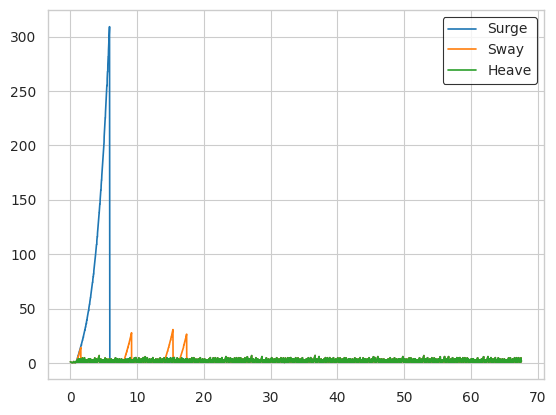

In [361]:
plt.plot(df_p["Timestamp"]-df_p["Timestamp"][0],df_p["k_d_1"],label="Surge")
plt.plot(df_p["Timestamp"]-df_p["Timestamp"][0],df_p["k_d_2"],label="Sway")
plt.plot(df_p["Timestamp"]-df_p["Timestamp"][0],df_p["k_d_3"],label="Heave")
plt.legend()

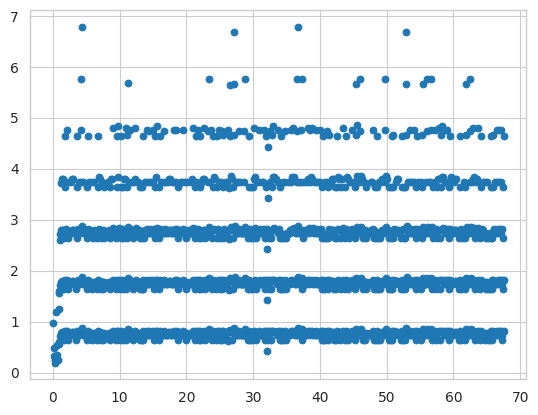

In [362]:
plt.scatter(df_p["Timestamp"]-df_p["Timestamp"][0],df_p["k_d_3"])

In [363]:
#1205
gt
div_flows_mean=gt["Z"].to_numpy()
#displacements=np.sqrt(gt_df["X"].to_numpy()**2 + gt_df["Y"].to_numpy()**2)
displacements_x=gt["X"].to_numpy()
displacements_z=gt["Y"].to_numpy()
# Calculate cumulative displacement
displacements=np.sqrt(gt["X"].to_numpy()**2 + gt["Y"].to_numpy()**2)
cumulative_displacement_x = np.cumsum(div_flows_mean)
cumulative_displacement_y =np.cumsum(displacements)
cumulative_displacement_z =np.cumsum(displacements_z)*0.001
cumulative_displacement_x*=0.5/abs(cumulative_displacement_x[0]-cumulative_displacement_x[cumulative_displacement_x.shape[0]-1])
cumulative_displacement_y*=6.5/abs(cumulative_displacement_y[0]-cumulative_displacement_y[cumulative_displacement_y.shape[0]-1])
cumulative_displacement_x+=1
cumulative_displacement_y=6.8-cumulative_displacement_y

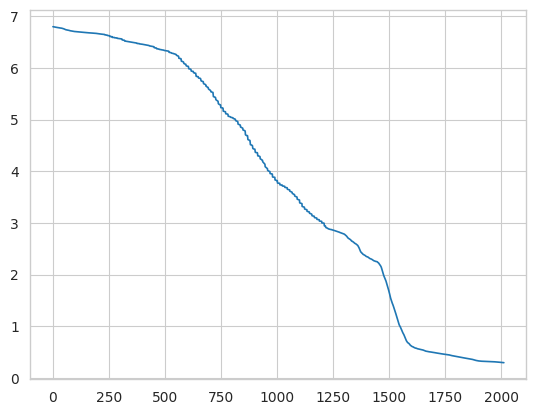

In [364]:
plt.plot(cumulative_displacement_y)

In [365]:
gt_abs_error_x=0.5*(np.abs(6.8-cumulative_displacement_y[0])+np.abs(0.3-cumulative_displacement_y[cumulative_displacement_y.shape[0]-1]))
print(gt_abs_error_x)

0.0003556318867668773


In [366]:
cumulative_displacement_y[-1]

0.29964436811323303

In [367]:
np.abs(0.3-cumulative_displacement_y[cumulative_displacement_y.shape[0]-1])

0.00035563188676696056

In [368]:
gt_interp_x_kf=np.interp(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.linspace(0,df_kf["Timestamp"][len(df_kf)-1]-df_kf["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_kf=np.interp(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.linspace(0,df_kf["Timestamp"][len(df_kf)-1]-df_kf["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_kf=np.interp(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.linspace(0,df_kf["Timestamp"][len(df_kf)-1]-df_kf["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [369]:
gt_interp_x_sbs=np.interp(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.linspace(0,df_sbs["Timestamp"][len(df_sbs)-1]-df_sbs["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_sbs=np.interp(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.linspace(0,df_sbs["Timestamp"][len(df_sbs)-1]-df_sbs["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_sbs=np.interp(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.linspace(0,df_sbs["Timestamp"][len(df_sbs)-1]-df_sbs["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [370]:
gt_interp_x_imu=np.interp(df_imu["Timestamp"]-df_imu["Timestamp"][0],np.linspace(0,df_imu["Timestamp"][len(df_imu)-1]-df_imu["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_imu=np.interp(df_imu["Timestamp"]-df_imu["Timestamp"][0],np.linspace(0,df_imu["Timestamp"][len(df_imu)-1]-df_imu["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_imu=np.interp(df_imu["Timestamp"]-df_imu["Timestamp"][0],np.linspace(0,df_imu["Timestamp"][len(df_imu)-1]-df_imu["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [371]:
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("bright")
markers = ['o', 's', '^',"*"]
sns.despine()

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
#fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)

<Figure size 640x480 with 0 Axes>

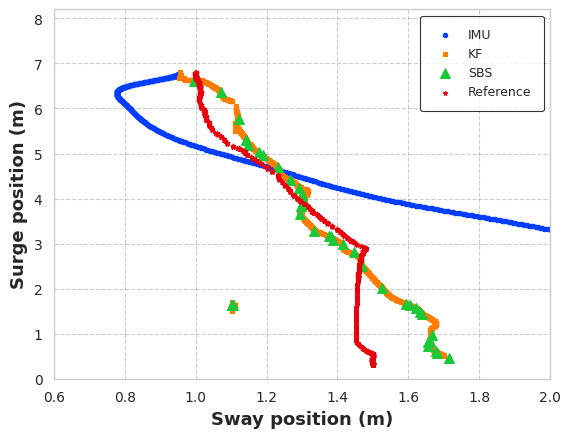

In [372]:
plt.grid(True, linestyle='--', alpha=0.4, color='gray')



plt.scatter(0.95+df_imu["Pose_X"],6.75+df_imu["Pose_Y"],label="IMU",s=10,color=palette[0],marker=markers[0])
plt.scatter(df_kf["Pose_X"],df_kf["Pose_Y"],label="KF",s=10,color=palette[1],marker=markers[1])
plt.scatter(df_sbs["Sonar_distance_1"]/1000,df_sbs["Sonar_distance_2"]/1000,label="SBS",s=50,color=palette[2],marker=markers[2])
plt.scatter(gt_interp_x_kf,gt_interp_y_kf,label="Reference",s=10,color=palette[3],marker=markers[3])

#plt.ylim(1.5,8.2)
#plt.xlim(1,1.4)
plt.ylim(0,8.2)
plt.xlim(0.6,2)
#plt.title("Trajectory Comparison")
plt.legend(
fontsize=9,
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.xlim([0,70])

plt.xlabel("Sway position (m)",fontsize=13, fontweight='bold')
plt.ylabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.savefig("/home/saab/2024_UWR/Analysis/2026_article/1205_Rope/Selected/trajectory_comparison_xy.png",dpi=300)

In [373]:
N = 20
segment_indices = np.linspace(0, len(gt_interp_x_kf), N+1, dtype=int)

for i in range(N):
    idx = segment_indices[i]
    error = np.sqrt((df_kf["Pose_X"][idx] - gt_interp_x_kf[idx])**2 + 
                    (df_kf["Pose_Y"][idx] - gt_interp_y_kf[idx])**2)
    print(f"Segment {i+1} error: {error:.3f}m")

Segment 1 error: 0.132m
Segment 2 error: 0.219m
Segment 3 error: 0.499m
Segment 4 error: 0.629m
Segment 5 error: 0.889m
Segment 6 error: 1.202m
Segment 7 error: 1.238m
Segment 8 error: 1.116m
Segment 9 error: 0.916m
Segment 10 error: 0.552m
Segment 11 error: 0.263m
Segment 12 error: 0.251m
Segment 13 error: 0.189m
Segment 14 error: 0.273m
Segment 15 error: 0.157m
Segment 16 error: 0.347m
Segment 17 error: 0.976m
Segment 18 error: 0.842m
Segment 19 error: 0.623m
Segment 20 error: 0.444m


In [374]:
np.sqrt(np.abs(df_kf["Pose_X"]**2-df_kf["Pose_Y"]**2))

0       6.607935
1       6.750190
2       6.639631
3       6.674493
4       6.612856
          ...   
1162    1.615077
1163    1.617010
1164    1.618934
1165    1.620867
1166    1.622620
Length: 1167, dtype: float64

In [375]:
sbs_interp=np.linspace

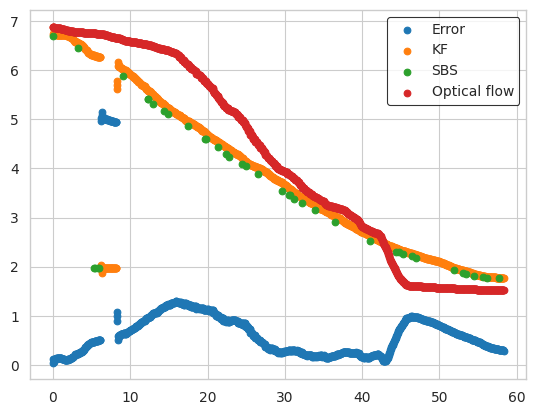

In [376]:
plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt((df_kf["Pose_X"] - gt_interp_x_kf)**2 + 
                    (df_kf["Pose_Y"] - gt_interp_y_kf)**2),label="Error")
plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt(np.abs(df_kf["Pose_X"]**2+df_kf["Pose_Y"]**2)),label="KF")
plt.scatter(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.sqrt(np.abs((df_sbs["Sonar_distance_1"]/1000)**2+(df_sbs["Sonar_distance_2"]/1000)**2)),label="SBS")
plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt(np.abs(gt_interp_x_kf**2+gt_interp_y_kf**2)),label="Optical flow")
plt.legend()

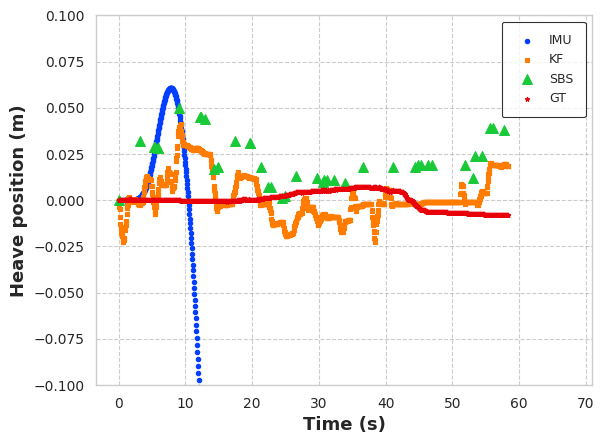

In [377]:
plt.grid(True, linestyle='--', alpha=0.4, color='gray')



plt.scatter(df_imu["Timestamp"]-df_imu["Timestamp"].iloc[0],df_imu["Pose_Z"]-df_imu["Pose_Z"].iloc[0],label="IMU",s=10,color=palette[0],marker=markers[0])
plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"].iloc[0],df_kf["Pose_Z"]-df_kf["Pose_Z"].iloc[0],label="KF",s=10,color=palette[1],marker=markers[1])
plt.scatter(df_sbs["Timestamp"]-df_sbs["Timestamp"].iloc[0],(df_sbs["Sonar_distance_3"]-df_sbs["Sonar_distance_3"].iloc[0])/1000,label="SBS",s=50,color=palette[2],marker=markers[2])
plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"].iloc[0],gt_interp_z_kf,label="GT",s=10,color=palette[3],marker=markers[3])

#plt.ylim(1.5,8.2)
#plt.xlim(-0.2,40)
plt.ylim(-0.1,0.1)
#plt.xlim(0.6,2)
#plt.title("Trajectory Comparison")
plt.legend(
fontsize=9,
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.xlim([0,70])

plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.savefig("/home/saab/2024_UWR/Analysis/2026_article/1205_Rope/Selected/trajectory_comparison_z.png",dpi=300)

Text(0.5, 0, 'Time (s)')

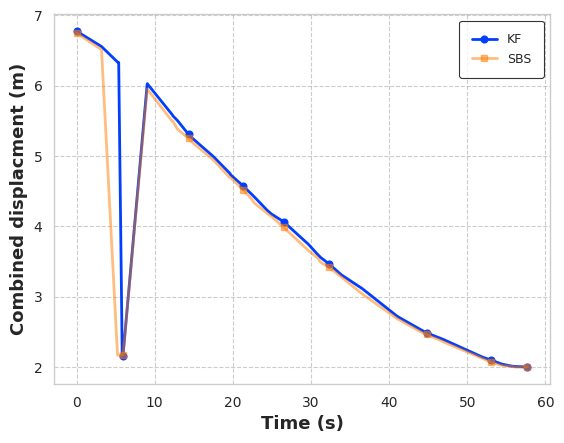

In [378]:

plt.grid(True, linestyle='--', alpha=0.4, color='gray')
plt.plot(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.sqrt(np.abs(df_sbs["Pose_X"]**2+df_sbs["Pose_Y"]**2+df_sbs["Pose_Z"]**2)),label="KF",markevery=5,linewidth=2,alpha=1,marker=markers[0],color=palette[0])
plt.plot(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.sqrt(np.abs((df_sbs["Sonar_distance_1"]/1000)**2+(df_sbs["Sonar_distance_2"]/1000)**2+(df_sbs["Sonar_distance_3"]/1000)**2)),label="SBS",markevery=5,linewidth=2,alpha=0.5,marker=markers[1],color=palette[1])
#plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt(np.abs(gt_interp_x_kf**2+gt_interp_y_kf**2)),label="Optical flow")
plt.legend(
fontsize=9,
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylabel("Combined displacment (m)",fontsize=13, fontweight='bold')
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')

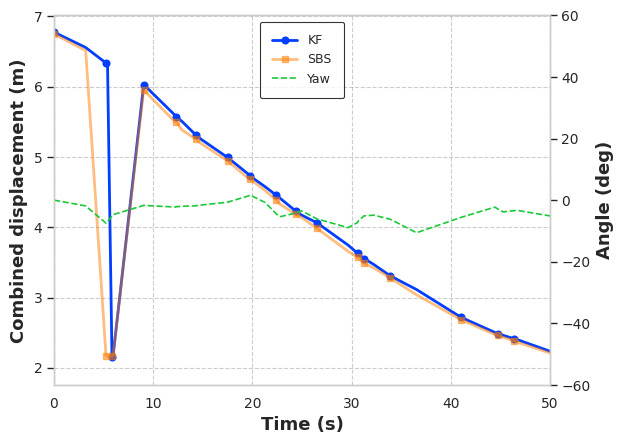

In [380]:
fig, ax1 = plt.subplots()

t = df_sbs["Timestamp"] - df_sbs["Timestamp"][0]

# LEFT AXIS (displacement)
ax1.grid(True, linestyle='--', alpha=0.4, color='gray')

ax1.plot(
    t,
    np.sqrt(np.abs(df_sbs["Pose_X"]**2 +
                   df_sbs["Pose_Y"]**2 +
                   df_sbs["Pose_Z"]**2)),
    label="KF",
    markevery=2,
    linewidth=2,
    alpha=1,
    marker=markers[0],
    color=palette[0]
)

ax1.plot(
    t,
    np.sqrt(np.abs((df_sbs["Sonar_distance_1"]/1000)**2 +
                   (df_sbs["Sonar_distance_2"]/1000)**2 +
                   (df_sbs["Sonar_distance_3"]/1000)**2)),
    label="SBS",
    markevery=2,
    linewidth=2,
    alpha=0.5,
    marker=markers[1],
    color=palette[1]
)

ax1.set_ylabel("Combined displacement (m)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Time (s)", fontsize=13, fontweight='bold')


# RIGHT AXIS (angles)
ax2 = ax1.twinx()
ax2.grid(False)  # Disable grid for the right axis

#ax2.plot(t, df_sbs["Angle_X"], label="Angle X", linestyle='--')
#ax2.plot(t, df_sbs["Angle_Y"], label="Angle Y", linestyle='--')
ax2.plot(t, df_sbs["Angle_Z"]-df_sbs["Angle_Z"][0], label="Yaw", linestyle='--',color=palette[2])
ax2.set_ylim(-60,60)
ax2.set_xlim(0,50)

ax2.set_ylabel("Angle (deg)", fontsize=13, fontweight='bold')


# COMBINED LEGEND
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=9,
    frameon=True,
    fancybox=True,
    borderpad=1,
    edgecolor='black',
    loc='upper center'
)

plt.show()

In [381]:
print("SBS measurements: ",len(df_sbs))
print("KF measurements: ",len(df_kf))
print("IMU measurements: ",len(df_imu))

SBS measurements:  41
KF measurements:  1167
IMU measurements:  1336


In [382]:
# Calculate RMSE and variance for KF
rmse_val_kf_x=np.sqrt(((gt_interp_x_kf[:] - df_kf["Pose_X"][:]) ** 2).mean())
rmse_val_kf_y=np.sqrt(((gt_interp_y_kf[:] - df_kf["Pose_Y"][:]) ** 2).mean())
rmse_val_kf_z=np.sqrt(((gt_interp_z_kf[:] - (df_kf["Pose_Z"][:]-df_kf["Pose_Z"][0])) ** 2).mean())
print("KF error _X",rmse_val_kf_x
      )
print("KF error _Y",rmse_val_kf_y
      )
print("KF error _Z",rmse_val_kf_z
      )
var_val_kf_x=np.var(gt_interp_x_kf[:] - df_kf["Pose_X"][:])
var_val_kf_y=np.var(gt_interp_y_kf[:] - df_kf["Pose_Y"][:])
var_val_kf_z=np.var(gt_interp_z_kf[:] - (df_kf["Pose_Z"][:]-df_kf["Pose_Z"][0]))
print("KF variance _X",var_val_kf_x
      )
print("KF variance _Y",var_val_kf_y
      )
print("KF variance _Z",var_val_kf_z
      )

KF error _X 0.12189796227792889
KF error _Y 1.15084294555001
KF error _Z 0.014563928260324053
KF variance _X 0.005402140966500112
KF variance _Y 1.1550563533530296
KF variance _Z 0.00020826618994805406


In [383]:
# Calculate RMSE and variance for SBS   
rmse_val_sbs_x=np.sqrt(((gt_interp_x_sbs[:] - df_sbs["Sonar_distance_1"][:]/1000) ** 2).mean())
rmse_val_sbs_y=np.sqrt(((gt_interp_y_sbs[:] - df_sbs["Sonar_distance_2"][:]/1000) ** 2).mean())
rmse_val_sbs_z=np.sqrt(((gt_interp_z_sbs[:] - (df_sbs["Sonar_distance_3"][:]/1000)) ** 2).mean())
print("SBS error _X",rmse_val_sbs_x
      )
print("SBS error _Y",rmse_val_sbs_y
      )
print("SBS error _Z",rmse_val_sbs_z
      )
var_val_sbs_x=np.var(gt_interp_x_sbs[:] -df_sbs["Sonar_distance_1"][:]/1000)
var_val_sbs_y=np.var(gt_interp_y_sbs[:] - df_sbs["Sonar_distance_2"][:]/1000)
var_val_sbs_z=np.var(gt_interp_z_sbs[:] - (df_sbs["Sonar_distance_3"][:]/1000))
print("SBS variance _X",var_val_sbs_x
      )
print("SBS variance _Y",var_val_sbs_y
      )
print("SBS variance _Z",var_val_sbs_z
      )

SBS error _X 0.13657509154650624
SBS error _Y 1.7440821251200662
SBS error _Z 0.8926170194391831
SBS variance _X 0.0045067522576977695
SBS variance _Y 2.405325067984976
SBS variance _Z 0.00022563275964351915


In [384]:
#RMSE Calculation and variance for IMU
rmse_val_imu_x=np.sqrt(((gt_interp_x_imu[:] - (1+df_imu["Pose_X"][:])) ** 2).mean())
rmse_val_imu_y=np.sqrt(((gt_interp_y_imu[:] - (6.75+df_imu["Pose_Y"][:]) ) ** 2).mean())
rmse_val_imu_z=np.sqrt(((gt_interp_z_imu[:] - df_imu["Pose_Z"][:]) ** 2).mean())
print("IMU error _X",rmse_val_imu_x
      )
print("IMU error _Y",rmse_val_imu_y
      )
print("IMU error _Z",rmse_val_imu_z
      )
var_val_imu_x=np.var(gt_interp_x_imu[:] - (1+df_imu["Pose_X"][:]))
var_val_imu_y=np.var(gt_interp_y_imu[:] - (6.75+df_imu["Pose_Y"][:]))
var_val_imu_z=np.var(gt_interp_z_imu[:] - df_imu["Pose_Z"][:])
print("IMU variance _X",var_val_imu_x
      )
print("IMU variance _Y",var_val_imu_y
      )
print("IMU variance _Z",var_val_imu_z
      )

IMU error _X 3.8264724481045476
IMU error _Y 2.9008247144347554
IMU error _Z 3.164758829481347
IMU variance _X 6.3391604246493145
IMU variance _Y 1.8381187968790555
IMU variance _Z 3.924359223360049


In [385]:
df_store=pd.DataFrame({
    "Method":["IMU","KF","SBS"],
    "RMSE_X":[rmse_val_imu_x,rmse_val_kf_x,rmse_val_sbs_x],
    "RMSE_Y":[rmse_val_imu_y,rmse_val_kf_y,rmse_val_sbs_y],
    "RMSE_Z":[rmse_val_imu_z,rmse_val_kf_z,rmse_val_sbs_z],
    "Variance_X":[var_val_imu_x,var_val_kf_x,var_val_sbs_x],
    "Variance_Y":[var_val_imu_y,var_val_kf_y,var_val_sbs_y],
    "Variance_Z":[var_val_imu_z,var_val_kf_z,var_val_sbs_z]
})
print(df_store)
df_store.to_csv("/home/saab/2024_UWR/Analysis/2026_article/1205_Rope/Selected/error_variance_summary.csv",index=False)

  Method    RMSE_X    RMSE_Y    RMSE_Z  Variance_X  Variance_Y  Variance_Z
0    IMU  3.826472  2.900825  3.164759    6.339160    1.838119    3.924359
1     KF  0.121898  1.150843  0.014564    0.005402    1.155056    0.000208
2    SBS  0.136575  1.744082  0.892617    0.004507    2.405325    0.000226


In [386]:
cases=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/*/output_case*.csv"))
confidence_cases=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/*/confidence_case*.csv"))
imus=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/*/output_IMU*.csv"))
gt=sorted(glob("/home/saab/2024_UWR/Analysis/gt/13*/*1302*gt.csv"))
print(cases)
print(confidence_cases)
print(imus)
print(gt)


gt=pd.read_csv(gt[0])


IMU_only=imus[-1]
KF=imus[0]
sbs=cases[0]
df_imu=pd.read_csv(IMU_only)
df_kf=pd.read_csv(KF)
df_sbs=pd.read_csv(sbs)

['/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/Condition_31_2026_04_16_15_44_31.bag/output_case_Condition_31_2026_04_16_15_44_31.bag.csv']
['/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/Condition_31_2026_04_16_15_44_31.bag/confidence_case_Condition_31_2026_04_16_15_44_31.bag.csv']
['/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/Condition_31_2026_04_16_15_44_31.bag/output_IMU_case_Condition_31_2026_04_16_15_44_31.bag.csv', '/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/Condition_31_IMU_only_2026_04_16_16_54_28.bag/output_IMU_case_Condition_31_IMU_only_2026_04_16_16_54_28.bag.csv']
['/home/saab/2024_UWR/Analysis/gt/13Nov/output_1302_6.5m_gt.csv']


In [387]:
# Find the index where calibration ends (~6.5m)
cal_end_idx_kf = (df_kf["Pose_Y"] - 6.5).abs().idxmin()

# Calibration phase
df_cal_kf = df_kf.iloc[:cal_end_idx_kf]

# Experimental phase  
df_exp_kf = df_kf.iloc[cal_end_idx_kf:]
df_exp_kf.reset_index(drop=True, inplace=True)

In [388]:
# Find the index where calibration ends (~6.5m)
cal_end_idx_sbs = (df_sbs["Pose_Y"] - 6.5).abs().idxmin()

# Calibration phase
df_cal_sbs = df_sbs.iloc[:cal_end_idx_sbs]

# Experimental phase  
df_exp_sbs = df_sbs.iloc[cal_end_idx_sbs:]
df_exp_sbs.reset_index(drop=True, inplace=True)

In [389]:
cal_end_idx_imu = (df_imu["Timestamp"] - df_exp_kf["Timestamp"]).abs().idxmin()
df_cal_imu = df_imu.iloc[:cal_end_idx_imu]

# Experimental phase  
df_exp_imu = df_imu.iloc[cal_end_idx_imu:]
df_exp_imu.reset_index(drop=True, inplace=True)

In [462]:
#1302
div_flows_mean=gt["Z"].to_numpy()
#displacements=np.sqrt(gt_df["X"].to_numpy()**2 + gt_df["Y"].to_numpy()**2)
displacements_x=gt["X"].to_numpy()
displacements_z=gt["Y"].to_numpy()
# Calculate cumulative displacement
displacements=np.sqrt(gt["X"].to_numpy()**2 + gt["Y"].to_numpy()**2)
cumulative_displacement_x = np.cumsum(div_flows_mean)
cumulative_displacement_y =np.cumsum(displacements)
cumulative_displacement_z =np.cumsum(displacements_z)*0.001
cumulative_displacement_x*=-0.1/abs(cumulative_displacement_x[0]-cumulative_displacement_x[cumulative_displacement_x.shape[0]-1])
cumulative_displacement_y*=5/abs(cumulative_displacement_y[0]-cumulative_displacement_y[cumulative_displacement_y.shape[0]-1])
cumulative_displacement_x+=1.25
cumulative_displacement_y=6.5-cumulative_displacement_y

In [463]:
gt_interp_x_kf_cal=np.interp(df_cal_kf["Timestamp"]-df_cal_kf["Timestamp"][0],np.linspace(0,df_cal_kf["Timestamp"][len(df_cal_kf)-1]-df_cal_kf["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_kf_cal=np.interp(df_cal_kf["Timestamp"]-df_cal_kf["Timestamp"][0],np.linspace(0,df_cal_kf["Timestamp"][len(df_cal_kf)-1]-df_cal_kf["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_kf_cal=np.interp(df_cal_kf["Timestamp"]-df_cal_kf["Timestamp"][0],np.linspace(0,df_cal_kf["Timestamp"][len(df_cal_kf)-1]-df_cal_kf["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [464]:
gt_interp_x_kf_exp=np.interp(df_exp_kf["Timestamp"]-df_exp_kf["Timestamp"][0],np.linspace(0,df_exp_kf["Timestamp"][len(df_exp_kf)-1]-df_exp_kf["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_kf_exp=np.interp(df_exp_kf["Timestamp"]-df_exp_kf["Timestamp"][0],np.linspace(0,df_exp_kf["Timestamp"][len(df_exp_kf)-1]-df_exp_kf["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_kf_exp=np.interp(df_exp_kf["Timestamp"]-df_exp_kf["Timestamp"][0],np.linspace(0,df_exp_kf["Timestamp"][len(df_exp_kf)-1]-df_exp_kf["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [465]:
gt_interp_x_sbs_cal=np.interp(df_cal_sbs["Timestamp"]-df_cal_sbs["Timestamp"][0],np.linspace(0,df_cal_sbs["Timestamp"][len(df_cal_sbs)-1]-df_cal_sbs["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_sbs_cal=np.interp(df_cal_sbs["Timestamp"]-df_cal_sbs["Timestamp"][0],np.linspace(0,df_cal_sbs["Timestamp"][len(df_cal_sbs)-1]-df_cal_sbs["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_sbs_cal=np.interp(df_cal_sbs["Timestamp"]-df_cal_sbs["Timestamp"][0],np.linspace(0,df_cal_sbs["Timestamp"][len(df_cal_sbs)-1]-df_cal_sbs["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [466]:
gt_interp_x_sbs_exp=np.interp(df_exp_sbs["Timestamp"]-df_exp_sbs["Timestamp"][0],np.linspace(0,df_exp_sbs["Timestamp"][len(df_exp_sbs)-1]-df_exp_sbs["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_sbs_exp=np.interp(df_exp_sbs["Timestamp"]-df_exp_sbs["Timestamp"][0],np.linspace(0,df_exp_sbs["Timestamp"][len(df_exp_sbs)-1]-df_exp_sbs["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_sbs_exp=np.interp(df_exp_sbs["Timestamp"]-df_exp_sbs["Timestamp"][0],np.linspace(0,df_exp_sbs["Timestamp"][len(df_exp_sbs)-1]-df_exp_sbs["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [467]:
gt_interp_x_sbs=np.interp(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.linspace(0,df_sbs["Timestamp"][len(df_sbs)-1]-df_sbs["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_sbs=np.interp(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.linspace(0,df_sbs["Timestamp"][len(df_sbs)-1]-df_sbs["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_sbs=np.interp(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.linspace(0,df_sbs["Timestamp"][len(df_sbs)-1]-df_sbs["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [468]:
gt_interp_x_imu=np.interp(df_imu["Timestamp"]-df_imu["Timestamp"][0],np.linspace(0,df_imu["Timestamp"][len(df_imu)-1]-df_imu["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_imu=np.interp(df_imu["Timestamp"]-df_imu["Timestamp"][0],np.linspace(0,df_imu["Timestamp"][len(df_imu)-1]-df_imu["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_imu=np.interp(df_imu["Timestamp"]-df_imu["Timestamp"][0],np.linspace(0,df_imu["Timestamp"][len(df_imu)-1]-df_imu["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [469]:
gt_interp_x_imu_exp=np.interp(df_exp_imu["Timestamp"]-df_exp_imu["Timestamp"][0],np.linspace(0,df_exp_imu["Timestamp"][len(df_exp_imu)-1]-df_exp_imu["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_imu_exp=np.interp(df_exp_imu["Timestamp"]-df_exp_imu["Timestamp"][0],np.linspace(0,df_exp_imu["Timestamp"][len(df_exp_imu)-1]-df_exp_imu["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_imu_exp=np.interp(df_exp_imu["Timestamp"]-df_exp_imu["Timestamp"][0],np.linspace(0,df_exp_imu["Timestamp"][len(df_exp_imu)-1]-df_exp_imu["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [470]:
gt_interp_x_imu_cal=np.interp(df_cal_imu["Timestamp"]-df_cal_imu["Timestamp"][0],np.linspace(0,df_cal_imu["Timestamp"][len(df_cal_imu)-1]-df_cal_imu["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y_imu_cal=np.interp(df_cal_imu["Timestamp"]-df_cal_imu["Timestamp"][0],np.linspace(0,df_cal_imu["Timestamp"][len(df_cal_imu)-1]-df_cal_imu["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z_imu_cal=np.interp(df_cal_imu["Timestamp"]-df_cal_imu["Timestamp"][0],np.linspace(0,df_cal_imu["Timestamp"][len(df_cal_imu)-1]-df_cal_imu["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [471]:
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("bright")
markers = ['o', 's', '^',"*"]
sns.despine()

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
#fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)

<Figure size 640x480 with 0 Axes>

In [472]:
df_exp_imu

,Timestamp,IMU_Linear_Acc_X,IMU_Linear_Acc_Y,IMU_Linear_Acc_Z,Filtered_X,Filtered_Y,Filtered_Z,Pose_X,Pose_Y,Pose_Z
0,1.731474e+09,0.222176,0.335903,-10.001534,-0.740172,0.966426,-0.006062,-0.534952,0.704137,-0.003117
1,1.731474e+09,0.017561,0.200699,-9.974304,-0.740152,0.966959,-0.005938,-0.555612,0.731275,-0.003270
2,1.731474e+09,-0.772828,-0.024618,-9.977520,-0.739613,0.967128,-0.005803,-0.576540,0.758762,-0.003424
3,1.731474e+09,-0.772828,-0.024618,-9.977520,-0.738539,0.966946,-0.005658,-0.598020,0.786971,-0.003584
4,1.731474e+09,-0.239804,0.273162,-9.937684,-0.736921,0.966422,-0.005504,-0.619973,0.815800,-0.003746
...,...,...,...,...,...,...,...,...,...,...
689,1.731474e+09,-0.394337,0.536361,-9.969599,-0.624921,1.077907,-0.009400,-122.374385,160.040900,-0.518642
690,1.731474e+09,-0.388038,0.522212,-9.993153,-0.624856,1.084029,-0.009047,-122.711521,160.505468,-0.519603
691,1.731474e+09,-0.429037,0.492338,-10.006981,-0.624896,1.090538,-0.008654,-123.032470,160.947871,-0.520523
692,1.731474e+09,-0.402917,0.442817,-9.997652,-0.625050,1.097412,-0.008225,-123.357428,161.395945,-0.521458


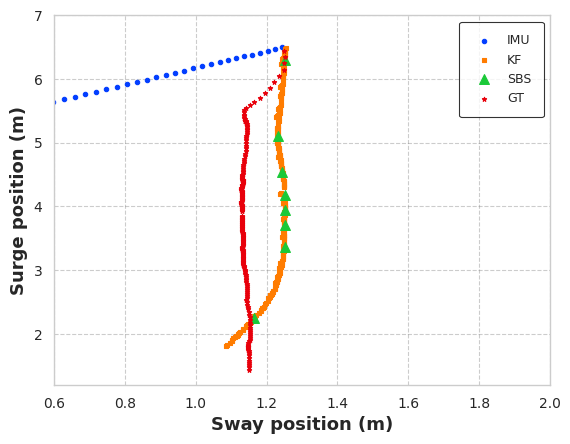

In [475]:
plt.grid(True, linestyle='--', alpha=0.4, color='gray')
plt.scatter(1.78+df_exp_imu["Pose_X"],7.2-df_exp_imu["Pose_Y"],label="IMU",s=10,color=palette[0],marker=markers[0])
plt.scatter(df_exp_kf["Pose_X"],df_exp_kf["Pose_Y"],label="KF",s=10,color=palette[1],marker=markers[1])
plt.scatter(df_exp_sbs["Sonar_distance_1"]/1000,df_exp_sbs["Sonar_distance_2"]/1000,label="SBS",s=50,color=palette[2],marker=markers[2])
plt.scatter(gt_interp_x_kf_exp,gt_interp_y_kf_exp,label="GT",s=10,color=palette[3],marker=markers[3])
plt.ylim(1.2,7)
#plt.xlim(1,1.4)
plt.xlim(0.6,2)
#plt.title("Trajectory Comparison")
plt.legend(
fontsize=9,
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.xlim([0,70])

plt.xlabel("Sway position (m)",fontsize=13, fontweight='bold')
plt.ylabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.savefig("/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/trajectory_comparison_xy.png",dpi=300)

plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt((df_kf["Pose_X"] - gt_interp_x_kf)**2 + 
                    (df_kf["Pose_Y"] - gt_interp_y_kf)**2),label="Error")
plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt(np.abs(df_kf["Pose_X"]**2+df_kf["Pose_Y"]**2)),label="KF")
plt.scatter(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.sqrt(np.abs((df_sbs["Sonar_distance_1"]/1000)**2+(df_sbs["Sonar_distance_2"]/1000)**2)),label="SBS")
plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt(np.abs(gt_interp_x_kf**2+gt_interp_y_kf**2)),label="Optical flow")
plt.legend()

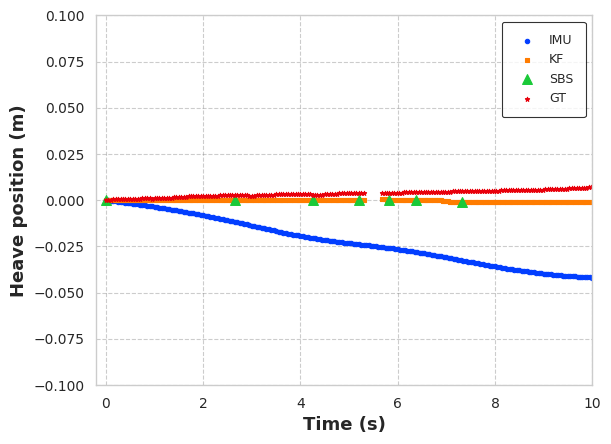

In [478]:
plt.grid(True, linestyle='--', alpha=0.4, color='gray')



plt.scatter(df_exp_imu["Timestamp"]-df_exp_imu["Timestamp"].iloc[0],df_exp_imu["Pose_Z"]-df_exp_imu["Pose_Z"].iloc[0],label="IMU",s=10,color=palette[0],marker=markers[0])
plt.scatter(df_exp_kf["Timestamp"]-df_exp_kf["Timestamp"].iloc[0],df_exp_kf["Pose_Z"]-df_exp_kf["Pose_Z"].iloc[0],label="KF",s=10,color=palette[1],marker=markers[1])
plt.scatter(df_exp_sbs["Timestamp"]-df_exp_sbs["Timestamp"].iloc[0],(df_exp_sbs["Sonar_distance_3"]-df_exp_sbs["Sonar_distance_3"].iloc[0])/1000,label="SBS",s=50,color=palette[2],marker=markers[2])
plt.scatter(df_exp_kf["Timestamp"]-df_exp_kf["Timestamp"].iloc[0],gt_interp_z_kf_exp,label="GT",s=10,color=palette[3],marker=markers[3])

#plt.ylim(1.5,8.2)
plt.xlim(-0.2,10)
plt.ylim(-0.1,0.1)
#plt.xlim(0.6,2)
#plt.title("Trajectory Comparison")
plt.legend(
fontsize=9,
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.xlim([0,70])

plt.xlabel("Time (s)",fontsize=13, fontweight='bold')
plt.ylabel("Heave position (m)",fontsize=13, fontweight='bold')
plt.savefig("/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/trajectory_comparison_z.png",dpi=300)

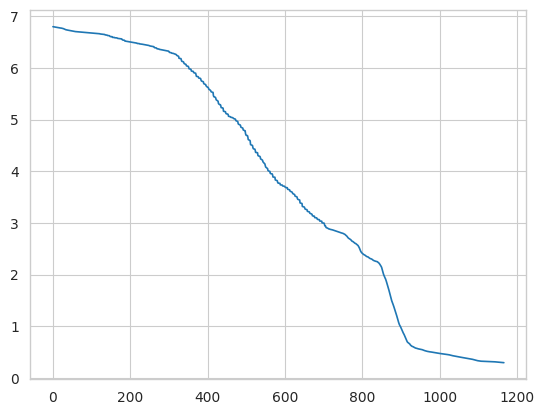

In [479]:
plt.plot(gt_interp_y_kf,label="GT")

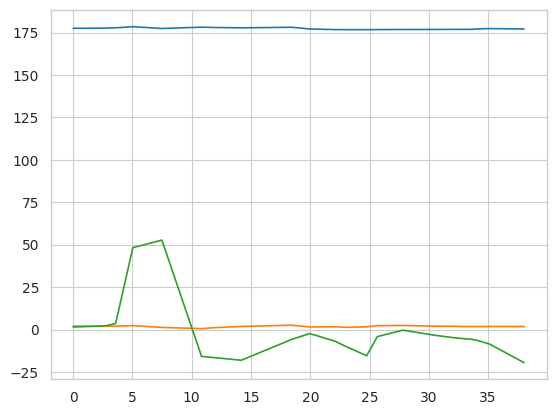

In [480]:
plt.plot(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],df_sbs["Angle_X"])
plt.plot(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],df_sbs["Angle_Y"])
plt.plot(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],df_sbs["Angle_Z"])

Text(0.5, 0, 'Time (s)')

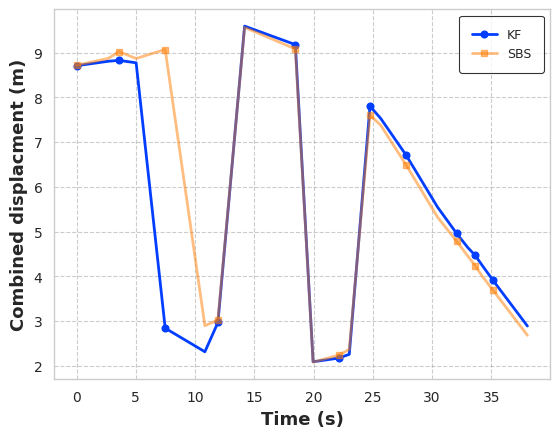

In [481]:

plt.grid(True, linestyle='--', alpha=0.4, color='gray')
#plt.plot(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],df_sbs["Angle_X"],label="KF",markevery=5,linewidth=2,alpha=1,marker=markers[0],color=palette[0])
plt.plot(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.sqrt(np.abs(df_sbs["Pose_X"]**2+df_sbs["Pose_Y"]**2+df_sbs["Pose_Z"]**2)),label="KF",markevery=2,linewidth=2,alpha=1,marker=markers[0],color=palette[0])
plt.plot(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.sqrt(np.abs((df_sbs["Sonar_distance_1"]/1000)**2+(df_sbs["Sonar_distance_2"]/1000)**2+(df_sbs["Sonar_distance_3"]/1000)**2)),label="SBS",markevery=2,linewidth=2,alpha=0.5,marker=markers[1],color=palette[1])
#plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt(np.abs(gt_interp_x_kf**2+gt_interp_y_kf**2)),label="Optical flow")
plt.legend(
fontsize=9,
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylabel("Combined displacment (m)",fontsize=13, fontweight='bold')
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')

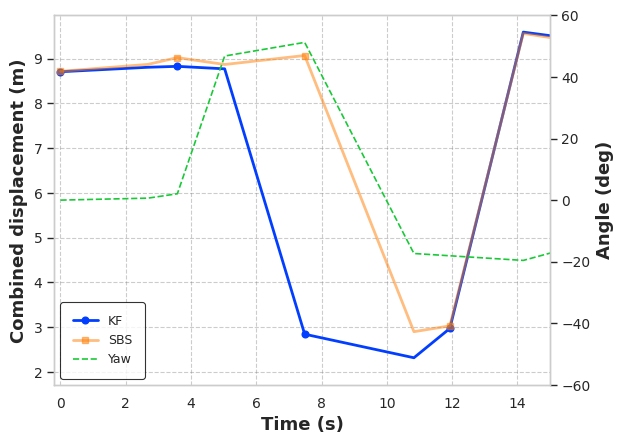

In [482]:
fig, ax1 = plt.subplots()

t = df_cal_sbs["Timestamp"] - df_cal_sbs["Timestamp"][0]

# LEFT AXIS (displacement)
ax1.grid(True, linestyle='--', alpha=0.4, color='gray')

ax1.plot(
    t,
    np.sqrt(np.abs(df_cal_sbs["Pose_X"]**2 +
                   df_cal_sbs["Pose_Y"]**2 +
                   df_cal_sbs["Pose_Z"]**2)),
    label="KF",
    markevery=2,
    linewidth=2,
    alpha=1,
    marker=markers[0],
    color=palette[0]
)

ax1.plot(
    t,
    np.sqrt(np.abs((df_cal_sbs["Sonar_distance_1"]/1000)**2 +
                   (df_cal_sbs["Sonar_distance_2"]/1000)**2 +
                   (df_cal_sbs["Sonar_distance_3"]/1000)**2)),
    label="SBS",
    markevery=2,
    linewidth=2,
    alpha=0.5,
    marker=markers[1],
    color=palette[1]
)

ax1.set_ylabel("Combined displacement (m)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Time (s)", fontsize=13, fontweight='bold')


# RIGHT AXIS (angles)
ax2 = ax1.twinx()
ax2.grid(False)  # Disable grid for the right axis

#ax2.plot(t, df_sbs["Angle_X"], label="Angle X", linestyle='--')
#ax2.plot(t, df_sbs["Angle_Y"], label="Angle Y", linestyle='--')
ax2.plot(t, df_cal_sbs["Angle_Z"]-df_cal_sbs["Angle_Z"][0], label="Yaw", linestyle='--',color=palette[2])
ax2.set_ylim(-60,60)
ax2.set_xlim(-0.2,15)
ax2.set_ylabel("Angle (deg)", fontsize=13, fontweight='bold')


# COMBINED LEGEND
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=9,
    frameon=True,
    fancybox=True,
    borderpad=1,
    edgecolor='black',
    loc='lower left'
)

plt.show()

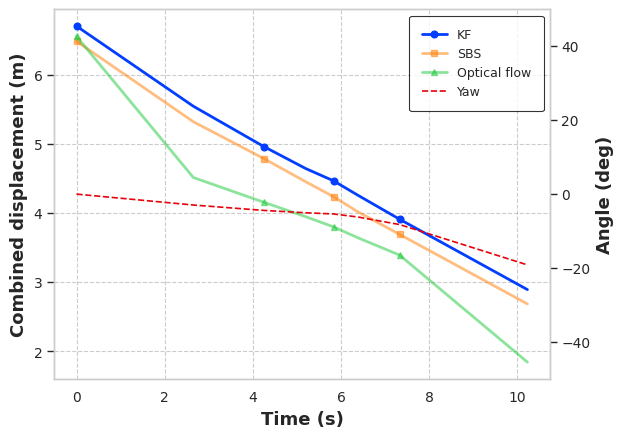

In [483]:
fig, ax1 = plt.subplots()

t = df_exp_sbs["Timestamp"] - df_exp_sbs["Timestamp"][0]

# LEFT AXIS (displacement)
ax1.grid(True, linestyle='--', alpha=0.4, color='gray')

ax1.plot(
    t,
    np.sqrt(np.abs(df_exp_sbs["Pose_X"]**2 +
                   df_exp_sbs["Pose_Y"]**2 +
                   df_exp_sbs["Pose_Z"]**2)),
    label="KF",
    markevery=2,
    linewidth=2,
    alpha=1,
    marker=markers[0],
    color=palette[0]
)

ax1.plot(
    t,
    np.sqrt(np.abs((df_exp_sbs["Sonar_distance_1"]/1000)**2 +
                   (df_exp_sbs["Sonar_distance_2"]/1000)**2 +
                   (df_exp_sbs["Sonar_distance_3"]/1000)**2)),
    label="SBS",
    markevery=2,
    linewidth=2,
    alpha=0.5,
    marker=markers[1],
    color=palette[1]
)
ax1.plot(
    t,
    np.sqrt(np.abs((gt_interp_x_sbs_exp)**2 +
                   (gt_interp_y_sbs_exp)**2 +
                   (gt_interp_z_sbs_exp)**2)),
    label="Optical flow",
    markevery=2,
    linewidth=2,
    alpha=0.5,
    marker=markers[2],
    color=palette[2]
)

ax1.set_ylabel("Combined displacement (m)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Time (s)", fontsize=13, fontweight='bold')


# RIGHT AXIS (angles)
ax2 = ax1.twinx()
ax2.grid(False)  # Disable grid for the right axis

#ax2.plot(t, df_exp_sbs["Angle_X"], label="Angle X", linestyle='--')
#ax2.plot(t, df_exp_sbs["Angle_Y"], label="Angle Y", linestyle='--')
ax2.plot(t, df_exp_sbs["Angle_Z"]-df_exp_sbs["Angle_Z"][0], label="Yaw", linestyle='--',color=palette[3])
ax2.set_ylim(-50,50)

ax2.set_ylabel("Angle (deg)", fontsize=13, fontweight='bold')


# COMBINED LEGEND
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=9,
    frameon=True,
    fancybox=True,
    borderpad=1,
    edgecolor='black',
    loc='upper right'
)

plt.show()

In [484]:
print("SBS measurements: ",len(df_exp_sbs))
print("KF measurements: ",len(df_exp_kf))
print("IMU measurements: ",len(df_exp_imu))

SBS measurements:  8
KF measurements:  230
IMU measurements:  694


In [485]:
#RMSE Calculation and variance for IMU
rmse_val_imu_x=np.sqrt(((gt_interp_x_imu[:] - (1.28+df_imu["Pose_X"][:])) ** 2).mean())
rmse_val_imu_y=np.sqrt(((gt_interp_y_imu[:] - (7.8+df_imu["Pose_Y"][:]) ) ** 2).mean())
rmse_val_imu_z=np.sqrt(((gt_interp_z_imu[:] - df_imu["Pose_Z"][:]) ** 2).mean())
print("IMU error _X",rmse_val_imu_x
      )
print("IMU error _Y",rmse_val_imu_y
      )
print("IMU error _Z",rmse_val_imu_z
      )
var_val_imu_x=np.var(gt_interp_x_imu[:] - (1.28+df_imu["Pose_X"][:]))
var_val_imu_y=np.var(gt_interp_y_imu[:] - (7.8+df_imu["Pose_Y"][:]))
var_val_imu_z=np.var(gt_interp_z_imu[:] - df_imu["Pose_Z"][:])
print("IMU variance _X",var_val_imu_x
      )
print("IMU variance _Y",var_val_imu_y
      )
print("IMU variance _Z",var_val_imu_z
      )

IMU error _X 53.243934458533715
IMU error _Y 72.46971346567297
IMU error _Z 0.2417238424620967
IMU variance _X 1363.943049743504
IMU variance _Y 2383.663373920852
IMU variance _Z 0.030519058454290256


In [486]:
#RMSE Calculation and variance for IMU_exp only
rmse_val_imu_x_exp=np.sqrt(((gt_interp_x_imu_exp[:] - (1.78+df_exp_imu["Pose_X"][:])) ** 2).mean())
rmse_val_imu_y_exp=np.sqrt(((gt_interp_y_imu_exp[:] - (7.2-df_exp_imu["Pose_Y"][:]) ) ** 2).mean())
rmse_val_imu_z_exp=np.sqrt(((gt_interp_z_imu_exp[:] - df_exp_imu["Pose_Z"][:]) ** 2).mean())
print("IMU error _X",rmse_val_imu_x_exp
      )
print("IMU error _Y",rmse_val_imu_y_exp 
      )
print("IMU error _Z",rmse_val_imu_z_exp 
      )
var_val_imu_x_exp=np.var(gt_interp_x_imu_exp[:] - (1.78+df_exp_imu["Pose_X"][:]))
var_val_imu_y_exp=np.var(gt_interp_y_imu_exp[:] - (7.2-df_exp_imu["Pose_Y"][:]))
var_val_imu_z_exp=np.var(gt_interp_z_imu_exp[:] - df_exp_imu["Pose_Z"][:])
print("IMU variance _X",var_val_imu_x_exp
      )
print("IMU variance _Y",var_val_imu_y_exp   
      )
print("IMU variance _Z",var_val_imu_z_exp   
      )

IMU error _X 56.10078308771914
IMU error _Y 69.66725289524368
IMU error _Z 0.2562034830685143
IMU variance _X 1326.8200306171116
IMU variance _Y 2131.4353215913247
IMU variance _Z 0.03056186331781645


In [487]:
# Calculate RMSE and variance for KF
rmse_val_kf_x=np.sqrt(((gt_interp_x_kf[:] - df_kf["Pose_X"][:]) ** 2).mean())
rmse_val_kf_y=np.sqrt(((gt_interp_y_kf[:] - df_kf["Pose_Y"][:]) ** 2).mean())
rmse_val_kf_z=np.sqrt(((gt_interp_z_kf[:] - (df_kf["Pose_Z"][:]-df_kf["Pose_Z"][0])) ** 2).mean())
print("KF error _X",rmse_val_kf_x
      )
print("KF error _Y",rmse_val_kf_y
      )
print("KF error _Z",rmse_val_kf_z
      )
var_val_kf_x=np.var(gt_interp_x_kf[:] - df_kf["Pose_X"][:])
var_val_kf_y=np.var(gt_interp_y_kf[:] - df_kf["Pose_Y"][:])
var_val_kf_z=np.var(gt_interp_z_kf[:] - (df_kf["Pose_Z"][:]-df_kf["Pose_Z"][0]))
print("KF variance _X",var_val_kf_x
      )
print("KF variance _Y",var_val_kf_y
      )
print("KF variance _Z",var_val_kf_z
      )

ValueError: operands could not be broadcast together with shapes (1167,) (782,) 

In [488]:
# Calculate RMSE and variance for KF
rmse_val_kf_x_exp=np.sqrt(((gt_interp_x_kf_exp[:] - df_exp_kf["Pose_X"][:]) ** 2).mean())
rmse_val_kf_y_exp=np.sqrt(((gt_interp_y_kf_exp[:] - df_exp_kf["Pose_Y"][:]) ** 2).mean())
rmse_val_kf_z_exp=np.sqrt(((gt_interp_z_kf_exp[:] - (df_exp_kf["Pose_Z"][:]-df_exp_kf["Pose_Z"][0])) ** 2).mean())
print("KF error _X",rmse_val_kf_x_exp
      )
print("KF error _Y",rmse_val_kf_y_exp   
      )
print("KF error _Z",rmse_val_kf_z_exp
      )
var_val_kf_x_exp=np.var(gt_interp_x_kf_exp[:] - df_exp_kf["Pose_X"][:])
var_val_kf_y_exp=np.var(gt_interp_y_kf_exp[:] - df_exp_kf["Pose_Y"][:])
var_val_kf_z_exp=np.var(gt_interp_z_kf_exp[:] - (df_exp_kf["Pose_Z"][:]-df_exp_kf["Pose_Z"][0]))
print("KF variance _X",var_val_kf_x_exp
      )
print("KF variance _Y",var_val_kf_y_exp   
      )
print("KF variance _Z",var_val_kf_z_exp   
      )

KF error _X 0.09680469964054089
KF error _Y 0.49025592226438575
KF error _Z 0.005474796054025906
KF variance _X 0.0020441504326469224
KF variance _Y 0.10608424411832372
KF variance _Z 7.827197015058002e-06


In [489]:
# Calculate RMSE and variance for SBS   
rmse_val_sbs_x=np.sqrt(((gt_interp_x_sbs[:] - df_sbs["Sonar_distance_1"][:]/1000) ** 2).mean())
rmse_val_sbs_y=np.sqrt(((gt_interp_y_sbs[:] - df_sbs["Sonar_distance_2"][:]/1000) ** 2).mean())
rmse_val_sbs_z=np.sqrt(((gt_interp_z_sbs[:] - (df_sbs["Sonar_distance_3"][:]/1000)) ** 2).mean())
print("SBS error _X",rmse_val_sbs_x
      )
print("SBS error _Y",rmse_val_sbs_y
      )
print("SBS error _Z",rmse_val_sbs_z
      )
var_val_sbs_x=np.var(gt_interp_x_sbs[:] -df_sbs["Sonar_distance_1"][:]/1000)
var_val_sbs_y=np.var(gt_interp_y_sbs[:] - df_sbs["Sonar_distance_2"][:]/1000)
var_val_sbs_z=np.var(gt_interp_z_sbs[:] - (df_sbs["Sonar_distance_3"][:]/1000))
print("SBS variance _X",var_val_sbs_x
      )
print("SBS variance _Y",var_val_sbs_y
      )
print("SBS variance _Z",var_val_sbs_z
      )

SBS error _X 1.7403391584526984
SBS error _Y 2.869259798077332
SBS error _Z 0.8788781805614161
SBS variance _X 2.5500658458856402
SBS variance _Y 6.036331197757065
SBS variance _Z 7.648723325236165e-06


In [490]:
# Calculate RMSE and variance for SBS   
rmse_val_sbs_x_exp=np.sqrt(((gt_interp_x_sbs_exp[:] - df_exp_sbs["Sonar_distance_1"][:]/1000) ** 2).mean())
rmse_val_sbs_y_exp=np.sqrt(((gt_interp_y_sbs_exp[:] - df_exp_sbs["Sonar_distance_2"][:]/1000) ** 2).mean())
rmse_val_sbs_z_exp=np.sqrt(((gt_interp_z_sbs_exp[:] - (df_exp_sbs["Sonar_distance_3"][:]/1000)) ** 2).mean())
print("SBS error _X",rmse_val_sbs_x_exp
      )
print("SBS error _Y",rmse_val_sbs_y_exp
      )
print("SBS error _Z",rmse_val_sbs_z_exp
      )
var_val_sbs_x_exp=np.var(gt_interp_x_sbs_exp[:] -df_exp_sbs["Sonar_distance_1"][:]/1000)
var_val_sbs_y_exp=np.var(gt_interp_y_sbs_exp[:] - df_exp_sbs["Sonar_distance_2"][:]/1000)
var_val_sbs_z_exp=np.var(gt_interp_z_sbs_exp[:] - (df_exp_sbs["Sonar_distance_3"][:]/1000))
print("SBS variance _X",var_val_sbs_x_exp
      )
print("SBS variance _Y",var_val_sbs_y_exp
      )
print("SBS variance _Z",var_val_sbs_z_exp
      )

SBS error _X 0.10054191333092355
SBS error _Y 0.4815583986720378
SBS error _Z 0.8826283441181288
SBS variance _X 0.002235761753462706
SBS variance _Y 0.08348484504185903
SBS variance _Z 6.026697853519809e-06


In [25]:
df_store=pd.DataFrame({
    "Method":["IMU","KF","SBS"],
    "RMSE_X":[rmse_val_imu_x,rmse_val_kf_x,rmse_val_sbs_x],
    "RMSE_Y":[rmse_val_imu_y,rmse_val_kf_y,rmse_val_sbs_y],
    "RMSE_Z":[rmse_val_imu_z,rmse_val_kf_z,rmse_val_sbs_z],
    "Variance_X":[var_val_imu_x,var_val_kf_x,var_val_sbs_x],
    "Variance_Y":[var_val_imu_y,var_val_kf_y,var_val_sbs_y],
    "Variance_Z":[var_val_imu_z,var_val_kf_z,var_val_sbs_z]
})
print(df_store)
df_store.to_csv("/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/error_variance_summary.csv",index=False)

  Method     RMSE_X     RMSE_Y    RMSE_Z   Variance_X   Variance_Y  Variance_Z
0    IMU  53.292772  72.161675  0.231927  1361.794821  2457.221490    0.028259
1     KF   0.492652   2.835475  0.009280     0.202458     7.775516    0.000059
2    SBS   1.699272   2.700962  0.887208     2.521223     7.028424    0.000071


In [491]:
df_store=pd.DataFrame({
    "Method":["IMU","KF","SBS"],
    "RMSE_X":[rmse_val_imu_x_exp,rmse_val_kf_x_exp,rmse_val_sbs_x_exp],
    "RMSE_Y":[rmse_val_imu_y_exp,rmse_val_kf_y_exp,rmse_val_sbs_y_exp],
    "RMSE_Z":[rmse_val_imu_z_exp,rmse_val_kf_z_exp,rmse_val_sbs_z_exp],
    "Variance_X":[var_val_imu_x_exp,var_val_kf_x_exp,var_val_sbs_x_exp],
    "Variance_Y":[var_val_imu_y_exp,var_val_kf_y_exp,var_val_sbs_y_exp],
    "Variance_Z":[var_val_imu_z_exp,var_val_kf_z_exp,var_val_sbs_z_exp]
})
print(df_store)
df_store.to_csv("/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/error_variance_summary_new.csv",index=False)

  Method     RMSE_X     RMSE_Y    RMSE_Z   Variance_X   Variance_Y  Variance_Z
0    IMU  56.100783  69.667253  0.256203  1326.820031  2131.435322    0.030562
1     KF   0.096805   0.490256  0.005475     0.002044     0.106084    0.000008
2    SBS   0.100542   0.481558  0.882628     0.002236     0.083485    0.000006


In [26]:
trial=pd.read_csv(imus[-1])
np.mean(np.abs(np.diff(trial["Pose_X"])))

0.15857106531891466

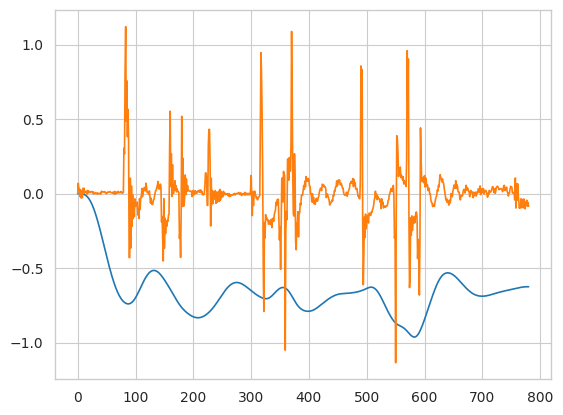

In [27]:
plt.plot(trial["Filtered_X"])
plt.plot(trial["IMU_Linear_Acc_X"]-trial["IMU_Linear_Acc_X"][0])

In [28]:
np.mean(np.diff(trial["Timestamp"]))

0.052490500914744845

In [337]:
cases=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/Stepper_aligned/Selected/*/output_case*.csv"))
confidence_cases=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/Stepper_aligned/Selected/*/confidence_case*.csv"))
imus=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/Stepper_aligned/Selected/*/output_IMU*.csv"))

print(cases)
print(confidence_cases)
print(imus)



IMU_only=imus[-1]
KF=imus[0]
sbs=cases[0]
df_imu=pd.read_csv(IMU_only)
df_kf=pd.read_csv(KF)
df_sbs=pd.read_csv(sbs)

['/home/saab/2024_UWR/Analysis/2026_article/Stepper_aligned/Selected/Condition_1_2026_04_20_17_04_54.bag/output_case_Condition_1_2026_04_20_17_04_54.bag.csv']
['/home/saab/2024_UWR/Analysis/2026_article/Stepper_aligned/Selected/Condition_1_2026_04_20_17_04_54.bag/confidence_case_Condition_1_2026_04_20_17_04_54.bag.csv']
['/home/saab/2024_UWR/Analysis/2026_article/Stepper_aligned/Selected/Condition_1_2026_04_20_17_04_54.bag/output_IMU_case_Condition_1_2026_04_20_17_04_54.bag.csv', '/home/saab/2024_UWR/Analysis/2026_article/Stepper_aligned/Selected/Condition_1_IMU_only_2026_04_20_17_00_16.bag/output_IMU_case_Condition_1_IMU_only_2026_04_20_17_00_16.bag.csv']


In [338]:
#stepper aligned
gt_final=np.sqrt(2)


In [339]:
gt_interp_x_kf=np.linspace(0,gt_final,df_kf.shape[0])
gt_interp_y_kf=np.linspace(0,gt_final,df_kf.shape[0])
gt_interp_z_kf=np.linspace(0,0,df_kf.shape[0])

In [340]:
gt_interp_x_sbs=np.linspace(0,gt_final,df_sbs.shape[0])
gt_interp_y_sbs=np.linspace(0,gt_final,df_sbs.shape[0])
gt_interp_z_sbs=np.linspace(0,0,df_sbs.shape[0])

In [341]:
gt_interp_x_imu=np.linspace(0,gt_final,df_imu.shape[0])
gt_interp_y_imu=np.linspace(0,gt_final,df_imu.shape[0])
gt_interp_z_imu=np.linspace(0,0,df_imu.shape[0])

In [342]:
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("bright")
markers = ['o', 's', '^',"*"]
sns.despine()

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
#fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)

<Figure size 640x480 with 0 Axes>

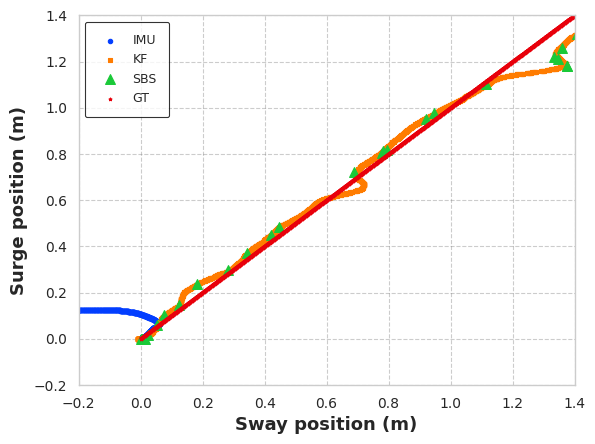

In [343]:
plt.grid(True, linestyle='--', alpha=0.4, color='gray')



plt.scatter(df_imu["Pose_X"],df_imu["Pose_Y"],label="IMU",s=10,color=palette[0],marker=markers[0])
plt.scatter(df_kf["Pose_X"]-df_kf["Pose_X"][0],df_kf["Pose_Y"]-df_kf["Pose_Y"][0],label="KF",s=10,color=palette[1],marker=markers[1])
plt.scatter((df_sbs["Sonar_distance_1"]-df_sbs["Sonar_distance_1"][0])/1000,(df_sbs["Sonar_distance_2"]-df_sbs["Sonar_distance_2"][0])/1000,label="SBS",s=50,color=palette[2],marker=markers[2])
plt.scatter(gt_interp_x_kf,gt_interp_y_kf,label="GT",s=5,color=palette[3],marker=markers[3])

plt.ylim(-0.2,1.4)
plt.xlim(-0.2,1.4)
#plt.title("Trajectory Comparison")
plt.legend(
fontsize=9,
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.xlim([0,70])

plt.xlabel("Sway position (m)",fontsize=13, fontweight='bold')
plt.ylabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.savefig("/home/saab/2024_UWR/Analysis/2026_article/Stepper_aligned/Selected/trajectory_comparison.png",dpi=300)

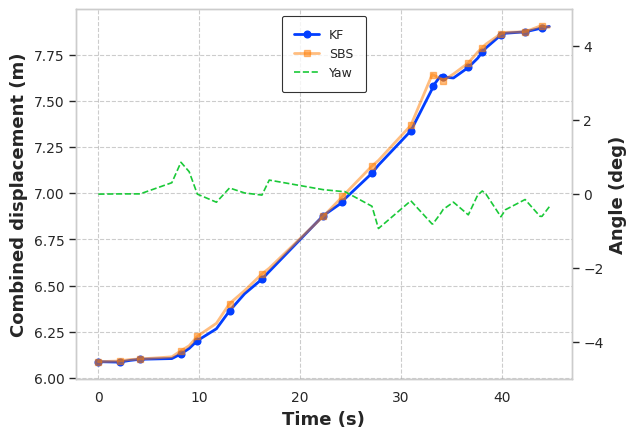

In [344]:
fig, ax1 = plt.subplots()

t = df_sbs["Timestamp"] - df_sbs["Timestamp"][0]

# LEFT AXIS (displacement)
ax1.grid(True, linestyle='--', alpha=0.4, color='gray')

ax1.plot(
    t,
    np.sqrt(np.abs(df_sbs["Pose_X"]**2 +
                   df_sbs["Pose_Y"]**2 +
                   df_sbs["Pose_Z"]**2)),
    label="KF",
    markevery=2,
    linewidth=2,
    alpha=1,
    marker=markers[0],
    color=palette[0]
)

ax1.plot(
    t,
    np.sqrt(np.abs((df_sbs["Sonar_distance_1"]/1000)**2 +
                   (df_sbs["Sonar_distance_2"]/1000)**2 +
                   (df_sbs["Sonar_distance_3"]/1000)**2)),
    label="SBS",
    markevery=2,
    linewidth=2,
    alpha=0.5,
    marker=markers[1],
    color=palette[1]
)

ax1.set_ylabel("Combined displacement (m)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Time (s)", fontsize=13, fontweight='bold')


# RIGHT AXIS (angles)
ax2 = ax1.twinx()
ax2.grid(False)  # Disable grid for the right axis

#ax2.plot(t, df_sbs["Angle_X"], label="Angle X", linestyle='--')
#ax2.plot(t, df_sbs["Angle_Y"], label="Angle Y", linestyle='--')
ax2.plot(t, df_sbs["Angle_Z"]-df_sbs["Angle_Z"][0], label="Yaw", linestyle='--',color=palette[2])
ax2.set_ylim(-5,5)
ax2.set_ylabel("Angle (deg)", fontsize=13, fontweight='bold')



# COMBINED LEGEND
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=9,
    frameon=True,
    fancybox=True,
    borderpad=1,
    edgecolor='black',
    loc='upper center'
)

plt.show()

In [345]:
print("SBS measurements: ",len(df_sbs))
print("KF measurements: ",len(df_kf))
print("IMU measurements: ",len(df_imu))

SBS measurements:  36
KF measurements:  1970
IMU measurements:  2189


In [346]:
#RMSE Calculation and variance for IMU
rmse_val_imu_x=np.sqrt(((gt_interp_x_imu[:] - (df_imu["Pose_X"][:])) ** 2).mean())
rmse_val_imu_y=np.sqrt(((gt_interp_y_imu[:] - (df_imu["Pose_Y"][:]) ) ** 2).mean())
rmse_val_imu_z=np.sqrt(((gt_interp_z_imu[:] - df_imu["Pose_Z"][:]) ** 2).mean())
print("IMU error _X",rmse_val_imu_x
      )
print("IMU error _Y",rmse_val_imu_y
      )
print("IMU error _Z",rmse_val_imu_z
      )
var_val_imu_x=np.var(gt_interp_x_imu[:] - (df_imu["Pose_X"][:]))
var_val_imu_y=np.var(gt_interp_y_imu[:] - (df_imu["Pose_Y"][:]))
var_val_imu_z=np.var(gt_interp_z_imu[:] - df_imu["Pose_Z"][:])
print("IMU variance _X",var_val_imu_x
      )
print("IMU variance _Y",var_val_imu_y
      )
print("IMU variance _Z",var_val_imu_z
      )

IMU error _X 2.671136914249639
IMU error _Y 1.7931906577156032
IMU error _Z 0.19058726090657221
IMU variance _X 3.3713770882362764
IMU variance _Y 1.6024454628206302
IMU variance _Z 0.013259963356274914


In [347]:
# Calculate RMSE and variance for KF
rmse_val_kf_x=np.sqrt(((gt_interp_x_kf[:] - (df_kf["Pose_X"][:]-df_kf["Pose_X"][0])) ** 2).mean())
rmse_val_kf_y=np.sqrt(((gt_interp_y_kf[:] - (df_kf["Pose_Y"][:]-df_kf["Pose_Y"][0])) ** 2).mean())
rmse_val_kf_z=np.sqrt(((gt_interp_z_kf[:] - (df_kf["Pose_Z"][:]-df_kf["Pose_Z"][0])) ** 2).mean())
print("KF error _X",rmse_val_kf_x
      )
print("KF error _Y",rmse_val_kf_y
      )
print("KF error _Z",rmse_val_kf_z
      )
var_val_kf_x=np.var(gt_interp_x_kf[:] - df_kf["Pose_X"][:])
var_val_kf_y=np.var(gt_interp_y_kf[:] - df_kf["Pose_Y"][:])
var_val_kf_z=np.var(gt_interp_z_kf[:] - (df_kf["Pose_Z"][:]-df_kf["Pose_Z"][0]))
print("KF variance _X",var_val_kf_x
      )
print("KF variance _Y",var_val_kf_y
      )
print("KF variance _Z",var_val_kf_z
      )

KF error _X 0.15752139903268148
KF error _Y 0.11816926518867042
KF error _Z 9.097274300727974e-06
KF variance _X 0.02461158834066743
KF variance _Y 0.0125943452101651
KF variance _Z 8.209210859094905e-11


In [348]:
# Calculate RMSE and variance for SBS   
rmse_val_sbs_x=np.sqrt(((gt_interp_x_sbs[:] - ((df_sbs["Sonar_distance_1"][:])-df_sbs["Sonar_distance_1"][0])/1000) ** 2).mean())
rmse_val_sbs_y=np.sqrt(((gt_interp_y_sbs[:] - ((df_sbs["Sonar_distance_2"][:])-df_sbs["Sonar_distance_2"][0])/1000) ** 2).mean())
rmse_val_sbs_z=np.sqrt(((gt_interp_z_sbs[:] - ((df_sbs["Sonar_distance_3"][:])-df_sbs["Sonar_distance_3"][0])/1000) ** 2).mean())
print("SBS error _X",rmse_val_sbs_x
      )
print("SBS error _Y",rmse_val_sbs_y
      )
print("SBS error _Z",rmse_val_sbs_z
      )
var_val_sbs_x=np.var(gt_interp_x_sbs[:] -((df_sbs["Sonar_distance_1"][:])-df_sbs["Sonar_distance_1"][0])/1000)
var_val_sbs_y=np.var(gt_interp_y_sbs[:] - ((df_sbs["Sonar_distance_2"][:])-df_sbs["Sonar_distance_2"][0])/1000)
var_val_sbs_z=np.var(gt_interp_z_sbs[:] - ((df_sbs["Sonar_distance_3"][:])-df_sbs["Sonar_distance_3"][0])/1000)
print("SBS variance _X",var_val_sbs_x
      )
print("SBS variance _Y",var_val_sbs_y
      )
print("SBS variance _Z",var_val_sbs_z
      )

SBS error _X 0.25481087810679964
SBS error _Y 0.18804875912150626
SBS error _Z 2.867737232804636e-07
SBS variance _X 0.048529249332377095
SBS variance _Y 0.028903731421773264
SBS variance _Z 5.601271979571721e-14


In [349]:
df_store=pd.DataFrame({
    "Method":["IMU","KF","SBS"],
    "RMSE_X":[rmse_val_imu_x,rmse_val_kf_x,rmse_val_sbs_x],
    "RMSE_Y":[rmse_val_imu_y,rmse_val_kf_y,rmse_val_sbs_y],
    "RMSE_Z":[rmse_val_imu_z,rmse_val_kf_z,rmse_val_sbs_z],
    "Variance_X":[var_val_imu_x,var_val_kf_x,var_val_sbs_x],
    "Variance_Y":[var_val_imu_y,var_val_kf_y,var_val_sbs_y],
    "Variance_Z":[var_val_imu_z,var_val_kf_z,var_val_sbs_z]
})
print(df_store)
df_store.to_csv("/home/saab/2024_UWR/Analysis/2026_article/Stepper_aligned/Selected/error_variance_summary.csv",index=False)

  Method    RMSE_X    RMSE_Y        RMSE_Z  Variance_X  Variance_Y  \
0    IMU  2.671137  1.793191  1.905873e-01    3.371377    1.602445   
1     KF  0.157521  0.118169  9.097274e-06    0.024612    0.012594   
2    SBS  0.254811  0.188049  2.867737e-07    0.048529    0.028904   

     Variance_Z  
0  1.325996e-02  
1  8.209211e-11  
2  5.601272e-14  


In [350]:
cases=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/*/output_case*.csv"))
confidence_cases=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/*/confidence_case*.csv"))
imus=sorted(glob("/home/*/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/*/output_IMU*.csv"))

print(cases)
print(confidence_cases)
print(imus)



IMU_only=imus[-1]
KF=imus[0]
sbs=cases[0]
df_imu=pd.read_csv(IMU_only)
df_kf=pd.read_csv(KF)
df_sbs=pd.read_csv(sbs)

['/home/saab/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/Condition_1_2026_04_20_17_34_03.bag/output_case_Condition_1_2026_04_20_17_34_03.bag.csv']
['/home/saab/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/Condition_1_2026_04_20_17_34_03.bag/confidence_case_Condition_1_2026_04_20_17_34_03.bag.csv']
['/home/saab/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/Condition_1_2026_04_20_17_34_03.bag/output_IMU_case_Condition_1_2026_04_20_17_34_03.bag.csv', '/home/saab/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/Condition_1_IMU_only_2026_04_20_17_29_09.bag/output_IMU_case_Condition_1_2026_04_20_17_29_09.bag.csv']


In [351]:
#stepper aligned
gt_final=2


In [352]:
gt_interp_x_kf=np.linspace(0,gt_final,df_kf.shape[0])
gt_interp_y_kf=np.linspace(0,gt_final,df_kf.shape[0])
gt_interp_z_kf=np.linspace(0,0,df_kf.shape[0])

In [353]:
gt_interp_x_sbs=np.linspace(0,gt_final,df_sbs.shape[0])
gt_interp_y_sbs=np.linspace(0,gt_final,df_sbs.shape[0])
gt_interp_z_sbs=np.linspace(0,0,df_sbs.shape[0])

In [354]:
gt_interp_x_imu=np.linspace(0,gt_final,df_imu.shape[0])
gt_interp_y_imu=np.linspace(0,gt_final,df_imu.shape[0])
gt_interp_z_imu=np.linspace(0,0,df_imu.shape[0])

In [355]:
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("bright")
markers = ['o', 's', '^',"*"]
sns.despine()

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})
#plt.figure(figsize=(7, 5))
#fig, ax = plt.subplots(1,1,figsize=(7, 5),sharey=True)

<Figure size 640x480 with 0 Axes>

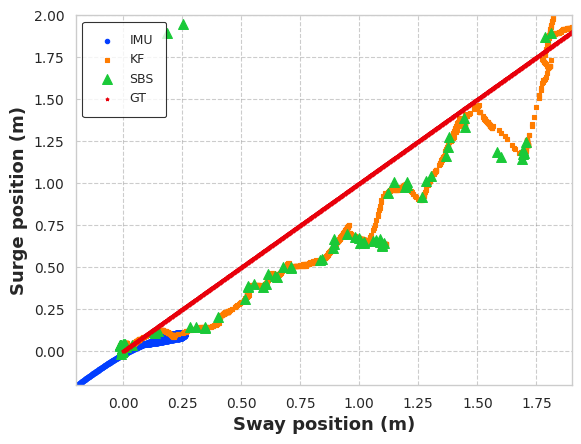

In [356]:
plt.grid(True, linestyle='--', alpha=0.4, color='gray')



plt.scatter(df_imu["Pose_X"],df_imu["Pose_Y"],label="IMU",s=10,color=palette[0],marker=markers[0])
plt.scatter(df_kf["Pose_X"]-df_kf["Pose_X"][0],df_kf["Pose_Y"]-df_kf["Pose_Y"][0],label="KF",s=10,color=palette[1],marker=markers[1])
plt.scatter((df_sbs["Sonar_distance_1"]-df_sbs["Sonar_distance_1"][0])/1000,(df_sbs["Sonar_distance_2"]-df_sbs["Sonar_distance_2"][0])/1000,label="SBS",s=50,color=palette[2],marker=markers[2])
plt.scatter(gt_interp_x_kf,gt_interp_y_kf,label="GT",s=5,color=palette[3],marker=markers[3])

plt.ylim(-0.2,2)
plt.xlim(-0.2,1.9)
#plt.title("Trajectory Comparison")
plt.legend(
fontsize=9,
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
#plt.xlim([0,70])

plt.xlabel("Sway position (m)",fontsize=13, fontweight='bold')
plt.ylabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.savefig("/home/saab/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/trajectory_comparison.png",dpi=300)

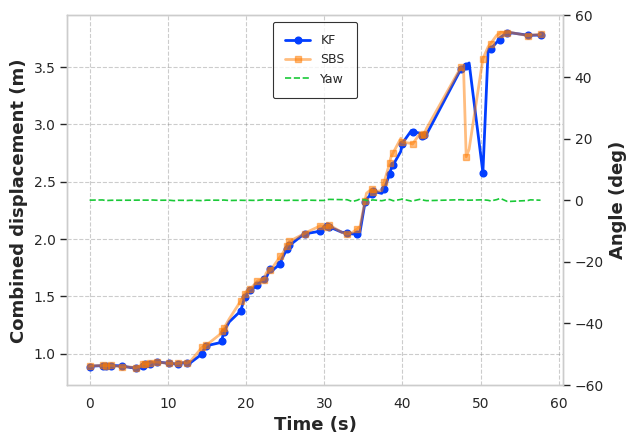

In [359]:
fig, ax1 = plt.subplots()

t = df_sbs["Timestamp"] - df_sbs["Timestamp"][0]

# LEFT AXIS (displacement)
ax1.grid(True, linestyle='--', alpha=0.4, color='gray')

ax1.plot(
    t,
    np.sqrt(np.abs(df_sbs["Pose_X"]**2 +
                   df_sbs["Pose_Y"]**2 +
                   df_sbs["Pose_Z"]**2)),
    label="KF",
    markevery=2,
    linewidth=2,
    alpha=1,
    marker=markers[0],
    color=palette[0]
)

ax1.plot(
    t,
    np.sqrt(np.abs((df_sbs["Sonar_distance_1"]/1000)**2 +
                   (df_sbs["Sonar_distance_2"]/1000)**2 +
                   (df_sbs["Sonar_distance_3"]/1000)**2)),
    label="SBS",
    markevery=2,
    linewidth=2,
    alpha=0.5,
    marker=markers[1],
    color=palette[1]
)

ax1.set_ylabel("Combined displacement (m)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Time (s)", fontsize=13, fontweight='bold')


# RIGHT AXIS (angles)
ax2 = ax1.twinx()
ax2.grid(False)  # Disable grid for the right axis

#ax2.plot(t, df_sbs["Angle_X"], label="Angle X", linestyle='--')
#ax2.plot(t, df_sbs["Angle_Y"], label="Angle Y", linestyle='--')
ax2.plot(t, df_sbs["Angle_Z"], label="Yaw", linestyle='--',color=palette[2])
ax2.set_ylim(-60,60)
ax2.set_ylabel("Angle (deg)", fontsize=13, fontweight='bold')


# COMBINED LEGEND
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=9,
    frameon=True,
    fancybox=True,
    borderpad=1,
    edgecolor='black',
    loc='upper center'
)

plt.show()

In [358]:
print("SBS measurements: ",len(df_sbs))
print("KF measurements: ",len(df_kf))
print("IMU measurements: ",len(df_imu))

SBS measurements:  99
KF measurements:  2273
IMU measurements:  2696


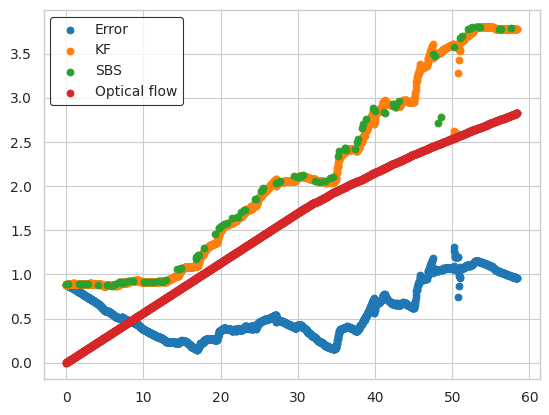

In [184]:
plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt((df_kf["Pose_X"] - gt_interp_x_kf)**2 + 
                    (df_kf["Pose_Y"] - gt_interp_y_kf)**2),label="Error")
plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt(np.abs(df_kf["Pose_X"]**2+df_kf["Pose_Y"]**2)),label="KF")
plt.scatter(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.sqrt(np.abs((df_sbs["Sonar_distance_1"]/1000)**2+(df_sbs["Sonar_distance_2"]/1000)**2)),label="SBS")
plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt(np.abs(gt_interp_x_kf**2+gt_interp_y_kf**2)),label="Optical flow")
plt.legend()

Text(0.5, 0, 'Time (s)')

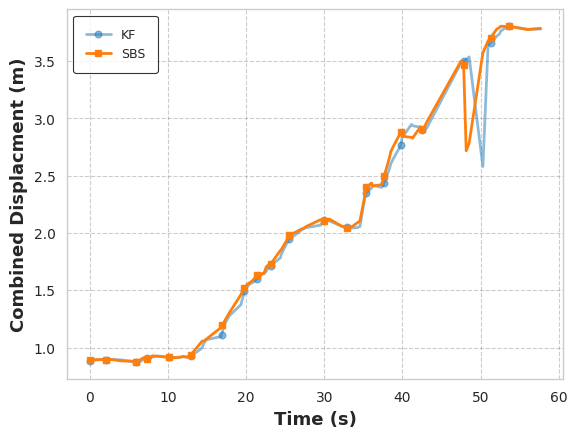

In [198]:

plt.grid(True, linestyle='--', alpha=0.4, color='gray')
plt.plot(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.sqrt(np.abs(df_sbs["Pose_X"]**2+df_sbs["Pose_Y"]**2)),label="KF",markevery=5,linewidth=2,alpha=0.5,marker=markers[0])
plt.plot(df_sbs["Timestamp"]-df_sbs["Timestamp"][0],np.sqrt(np.abs((df_sbs["Sonar_distance_1"]/1000)**2+(df_sbs["Sonar_distance_2"]/1000)**2)),label="SBS",markevery=5,linewidth=2,alpha=1,marker=markers[1])
#plt.scatter(df_kf["Timestamp"]-df_kf["Timestamp"][0],np.sqrt(np.abs(gt_interp_x_kf**2+gt_interp_y_kf**2)),label="Optical flow")
plt.legend(
fontsize=9,
frameon=True,
fancybox=True,
borderpad=1,
edgecolor='black'
)
plt.ylabel("Combined Displacment (m)",fontsize=13, fontweight='bold')
plt.xlabel("Time (s)",fontsize=13, fontweight='bold')

In [47]:
#RMSE Calculation and variance for IMU
rmse_val_imu_x=np.sqrt(((gt_interp_x_imu[:] - (df_imu["Pose_X"][:])) ** 2).mean())
rmse_val_imu_y=np.sqrt(((gt_interp_y_imu[:] - (df_imu["Pose_Y"][:]) ) ** 2).mean())
rmse_val_imu_z=np.sqrt(((gt_interp_z_imu[:] - df_imu["Pose_Z"][:]) ** 2).mean())
print("IMU error _X",rmse_val_imu_x
      )
print("IMU error _Y",rmse_val_imu_y
      )
print("IMU error _Z",rmse_val_imu_z
      )
var_val_imu_x=np.var(gt_interp_x_imu[:] - (df_imu["Pose_X"][:]))
var_val_imu_y=np.var(gt_interp_y_imu[:] - (df_imu["Pose_Y"][:]))
var_val_imu_z=np.var(gt_interp_z_imu[:] - df_imu["Pose_Z"][:])
print("IMU variance _X",var_val_imu_x
      )
print("IMU variance _Y",var_val_imu_y
      )
print("IMU variance _Z",var_val_imu_z
      )

IMU error _X 1.927243508669771
IMU error _Y 3.504218842580707
IMU error _Z 0.1910671391068717
IMU variance _X 1.5969250259681447
IMU variance _Y 6.743092029553863
IMU variance _Z 0.021441423773966146


In [48]:
# Calculate RMSE and variance for KF
rmse_val_kf_x=np.sqrt(((gt_interp_x_kf[:] - (df_kf["Pose_X"][:]-df_kf["Pose_X"][0])) ** 2).mean())
rmse_val_kf_y=np.sqrt(((gt_interp_y_kf[:] - (df_kf["Pose_Y"][:]-df_kf["Pose_Y"][0])) ** 2).mean())
rmse_val_kf_z=np.sqrt(((gt_interp_z_kf[:] - (df_kf["Pose_Z"][:]-df_kf["Pose_Z"][0])) ** 2).mean())
print("KF error _X",rmse_val_kf_x
      )
print("KF error _Y",rmse_val_kf_y
      )
print("KF error _Z",rmse_val_kf_z
      )
var_val_kf_x=np.var(gt_interp_x_kf[:] - df_kf["Pose_X"][:])
var_val_kf_y=np.var(gt_interp_y_kf[:] - df_kf["Pose_Y"][:])
var_val_kf_z=np.var(gt_interp_z_kf[:] - (df_kf["Pose_Z"][:]-df_kf["Pose_Z"][0]))
print("KF variance _X",var_val_kf_x
      )
print("KF variance _Y",var_val_kf_y
      )
print("KF variance _Z",var_val_kf_z
      )

KF error _X 0.266152106279644
KF error _Y 0.4214790280860409
KF error _Z 0.00011261640178926474
KF variance _X 0.042057207327124195
KF variance _Y 0.06619133992432549
KF variance _Z 1.2682453750455277e-08


In [49]:
# Calculate RMSE and variance for SBS   
rmse_val_sbs_x=np.sqrt(((gt_interp_x_sbs[:] - ((df_sbs["Sonar_distance_1"][:])-df_sbs["Sonar_distance_1"][0])/1000) ** 2).mean())
rmse_val_sbs_y=np.sqrt(((gt_interp_y_sbs[:] - ((df_sbs["Sonar_distance_2"][:])-df_sbs["Sonar_distance_2"][0])/1000) ** 2).mean())
rmse_val_sbs_z=np.sqrt(((gt_interp_z_sbs[:] - ((df_sbs["Sonar_distance_3"][:])-df_sbs["Sonar_distance_3"][0])/1000) ** 2).mean())
print("SBS error _X",rmse_val_sbs_x
      )
print("SBS error _Y",rmse_val_sbs_y
      )
print("SBS error _Z",rmse_val_sbs_z
      )
var_val_sbs_x=np.var(gt_interp_x_sbs[:] -((df_sbs["Sonar_distance_1"][:])-df_sbs["Sonar_distance_1"][0])/1000)
var_val_sbs_y=np.var(gt_interp_y_sbs[:] - ((df_sbs["Sonar_distance_2"][:])-df_sbs["Sonar_distance_2"][0])/1000)
var_val_sbs_z=np.var(gt_interp_z_sbs[:] - ((df_sbs["Sonar_distance_3"][:])-df_sbs["Sonar_distance_3"][0])/1000)
print("SBS variance _X",var_val_sbs_x
      )
print("SBS variance _Y",var_val_sbs_y
      )
print("SBS variance _Z",var_val_sbs_z
      )

SBS error _X 0.31397255440328414
SBS error _Y 0.35707654137161376
SBS error _Z 0.0
SBS variance _X 0.07309500636216677
SBS variance _Y 0.04071092617861024
SBS variance _Z 0.0


In [50]:
df_store=pd.DataFrame({
    "Method":["IMU","KF","SBS"],
    "RMSE_X":[rmse_val_imu_x,rmse_val_kf_x,rmse_val_sbs_x],
    "RMSE_Y":[rmse_val_imu_y,rmse_val_kf_y,rmse_val_sbs_y],
    "RMSE_Z":[rmse_val_imu_z,rmse_val_kf_z,rmse_val_sbs_z],
    "Variance_X":[var_val_imu_x,var_val_kf_x,var_val_sbs_x],
    "Variance_Y":[var_val_imu_y,var_val_kf_y,var_val_sbs_y],
    "Variance_Z":[var_val_imu_z,var_val_kf_z,var_val_sbs_z]
})
print(df_store)
df_store.to_csv("/home/saab/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/error_variance_summary.csv",index=False)

  Method    RMSE_X    RMSE_Y    RMSE_Z  Variance_X  Variance_Y    Variance_Z
0    IMU  1.927244  3.504219  0.191067    1.596925    6.743092  2.144142e-02
1     KF  0.266152  0.421479  0.000113    0.042057    0.066191  1.268245e-08
2    SBS  0.313973  0.357077  0.000000    0.073095    0.040711  0.000000e+00


-6.178665671459999e-07
-0.343837559223175
7.635832168743239e-07
0.4249276518821716
0.0
-9.9898099899292


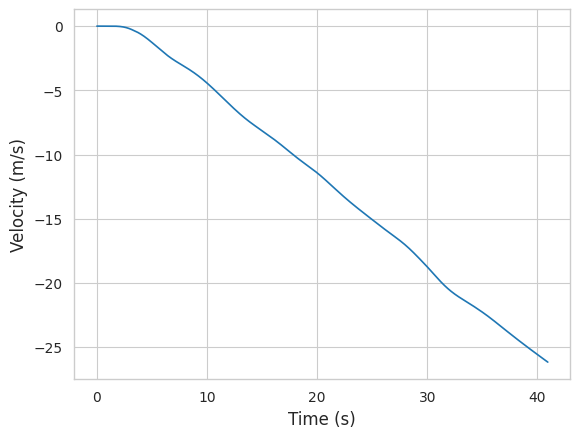

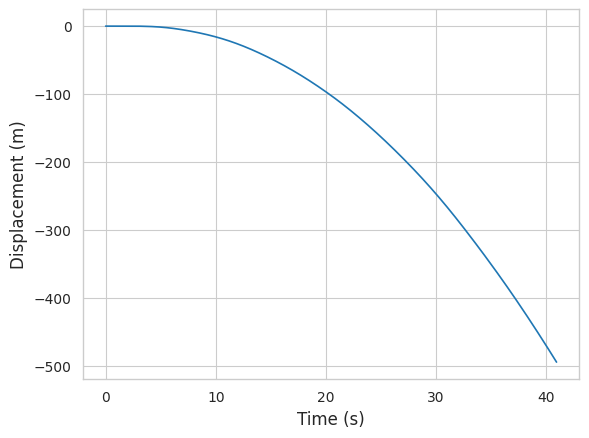

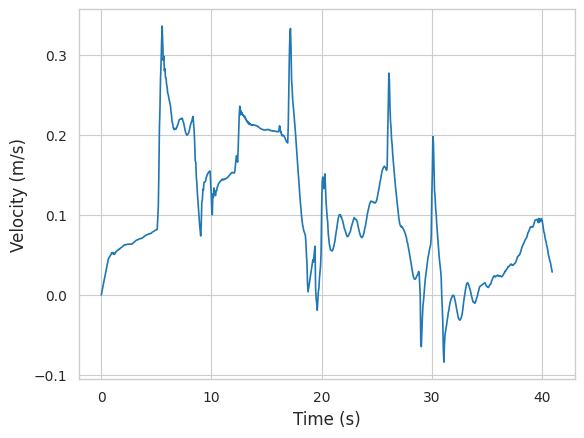

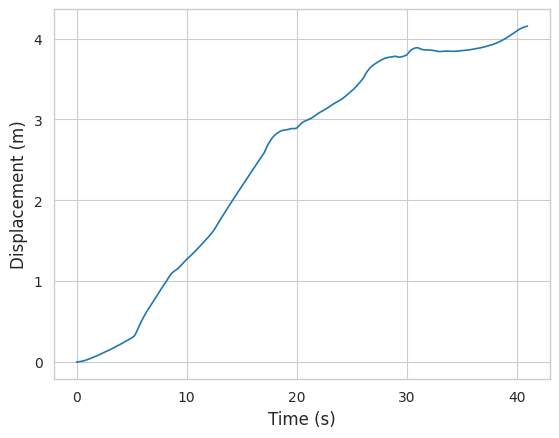

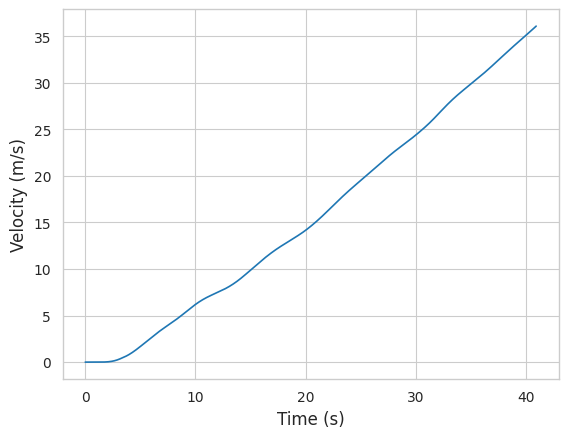

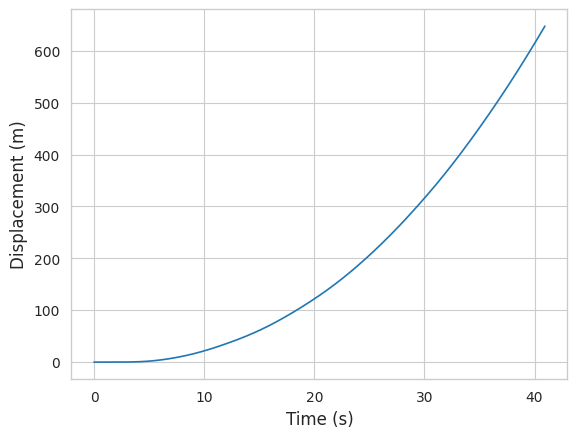

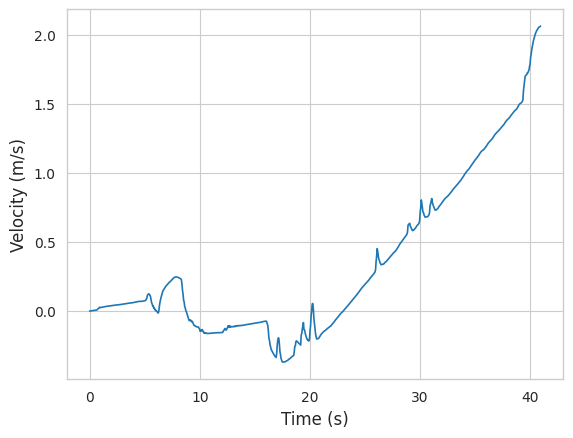

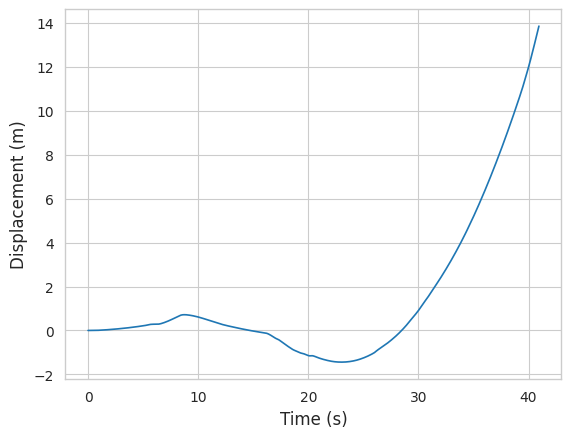

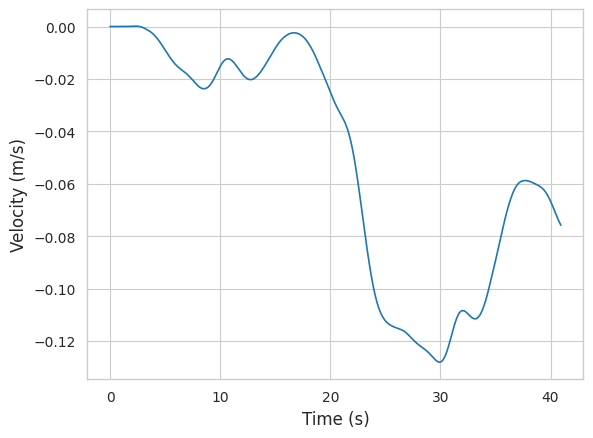

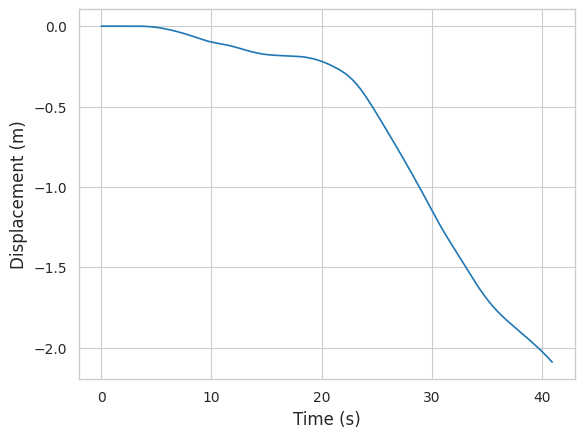

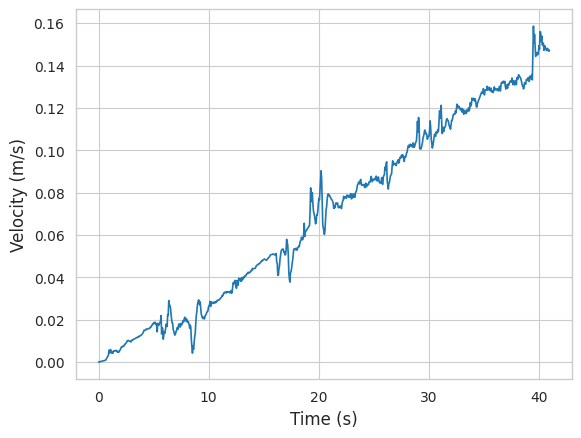

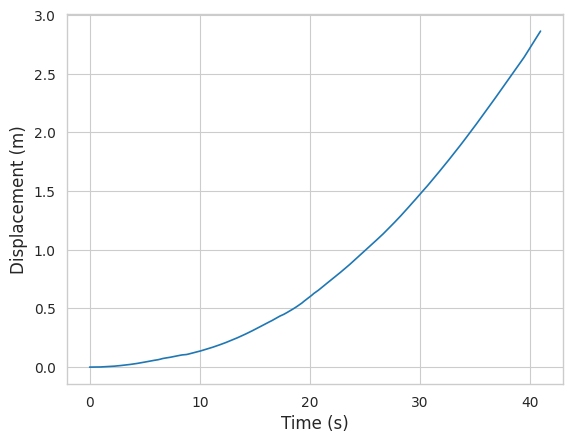

In [51]:
def create_v_d(accs,imus):
    window=0
    iterator=0
    value=0
    vels=[]
    prev_time=imus.iloc[0]["Timestamp"]
    
    prev_acc=0
    prev_vel=0
    for x in imus.iloc:
        bias=imus.iloc[window][accs]
            #Avg acc * dt = dv
        #vel_d=0.5*(prev_acc+x[accs]-2*bias)*(x["Timestamp"]-prev_time)
        vel_d = (x[accs] - bias) * (x["Timestamp"]-prev_time)
        #vel=vel_d
        vel=prev_vel+vel_d
        prev_vel=vel
        prev_time=x["Timestamp"]
        prev_acc=x[accs]
        vels.append(vel)
        iterator+=1
        if(value!=0):
            if(iterator%value==0):
                window+=value
    plt.figure()
    plt.ylabel("Velocity (m/s)")
    plt.xlabel("Time (s)")
    plt.plot(np.array(imus.iloc[:]["Timestamp"]-imus["Timestamp"][0]),vels)
    i=0
    prev_s=0
    prev_v=0
    prev_time=imus.iloc[0]["Timestamp"]
    dists=[]
    window=0
    iterator=0
    for x in imus.iloc:
        bias=imus.iloc[window][accs]
            #Avg acc * dt = dv
        #bias=0
        # velocity


# position
        s = prev_s + prev_vel * (x["Timestamp"]-prev_time)+ + 0.5 * (x[accs] - bias) * (x["Timestamp"]-prev_time)**2
        #s=prev_s+vels[i]*(x["Timestamp"]-prev_time)+0.5*0.5*(prev_acc+x[accs]-2*bias)*np.square(x["Timestamp"]-prev_time)
        #s=prev_s+(vels[i])*(x["Timestamp"]-prev_time)
        prev_s=s
        prev_vel=vels[i]
        prev_acc=x[accs]
        prev_time=x["Timestamp"]
        dists.append(s)
        i+=1
        iterator+=1
        if(value!=0):
            if(iterator%value==0):
                window+=value
    plt.figure()
    plt.ylabel("Displacement (m)")
    plt.xlabel("Time (s)")
    plt.plot(np.array(imus.iloc[:]["Timestamp"]-imus["Timestamp"][0]),dists)
    print(bias)
    return vels,dists
#z_v,z_d=create_v_d("IMU_Raw_z",df2)
#y_v,y_d=create_v_d("IMU_Raw_y",df2)
#x_v,x_d=create_v_d("IMU_Raw_x",df2)
#z_v_st,z_d_st=create_v_d("IMU_Linear_Acc_Z",df2_st)
#y_v_st,y_d_st=create_v_d("IMU_Linear_Acc_Y",df2_st)
#x_v_st,x_d_st=create_v_d("IMU_Linear_Acc_X",df2_st)
x_v_nt_st,x_d_nt_st=create_v_d("Filtered_X",trial)

y_v_nt_st,y_d_nt_st=create_v_d("IMU_Linear_Acc_X",trial)

x_v_nt_st,x_d_nt_st=create_v_d("Filtered_Y",trial)

y_v_nt_st,y_d_nt_st=create_v_d("IMU_Linear_Acc_Y",trial)

z_v_nt_st,z_d_nt_st=create_v_d("Filtered_Z",trial)

z_v_nt_st,z_d_nt_st=create_v_d("IMU_Linear_Acc_Z",trial)

-6.178665671459999e-07
-0.343837559223175
7.635832168743239e-07
0.4249276518821716
0.0
-9.9898099899292


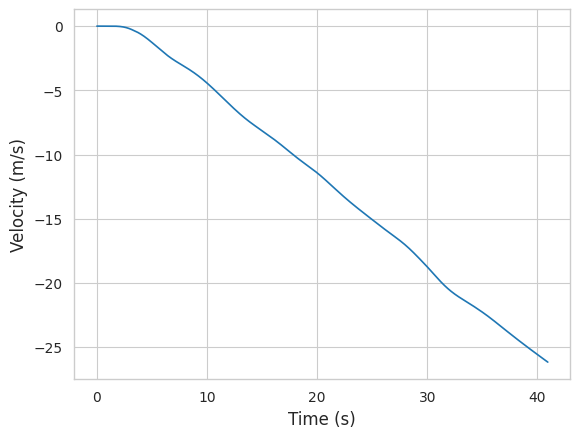

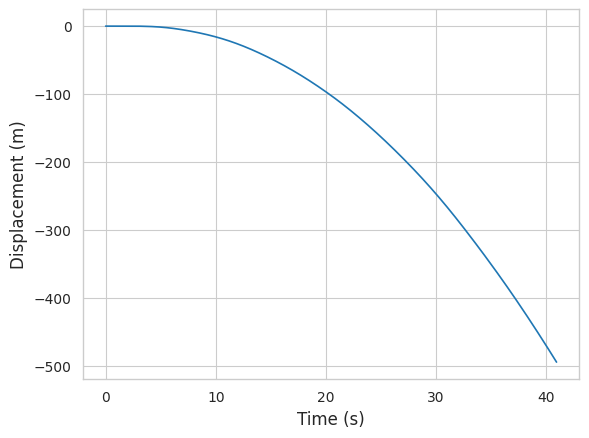

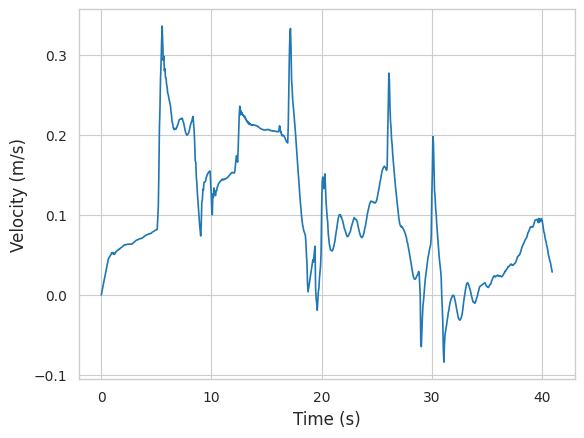

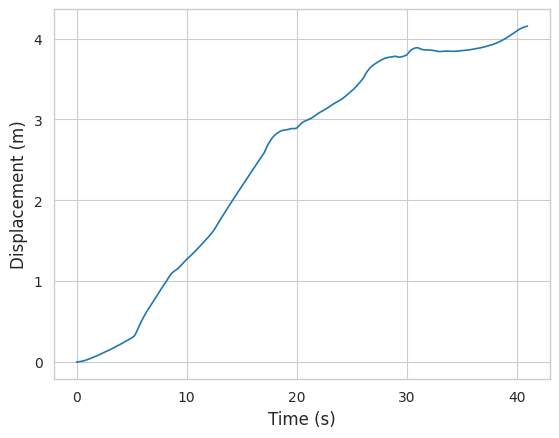

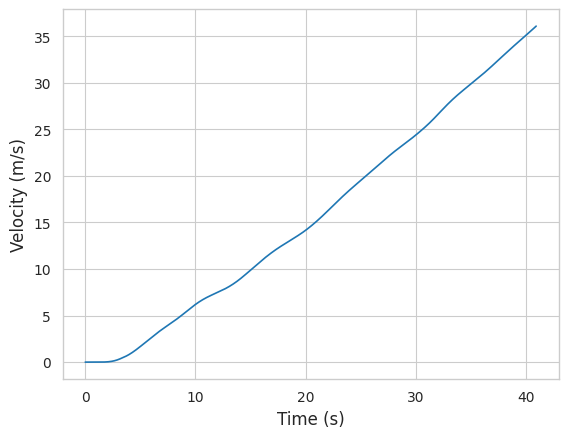

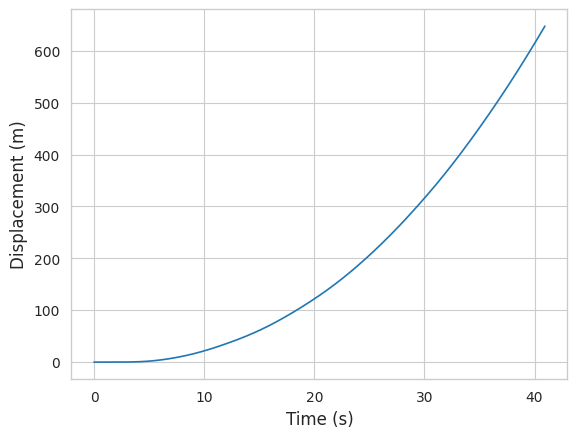

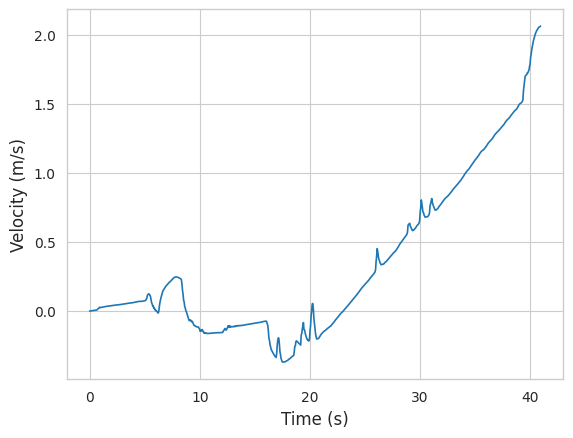

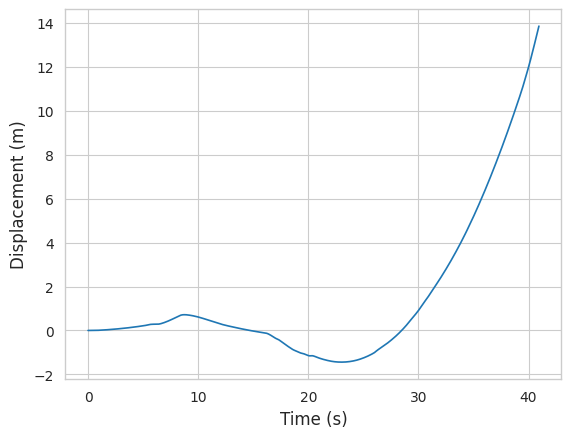

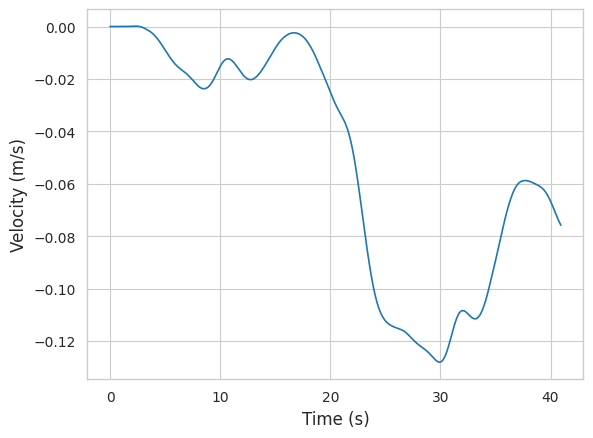

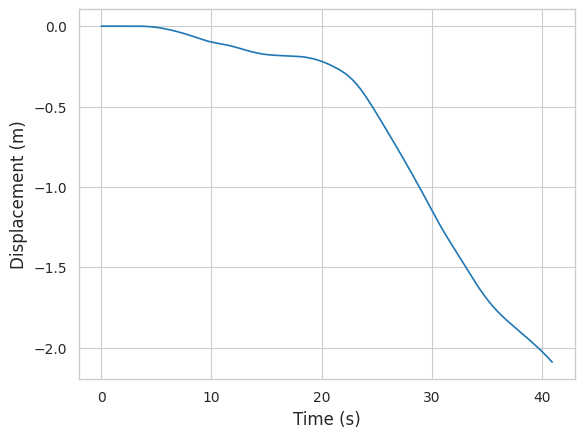

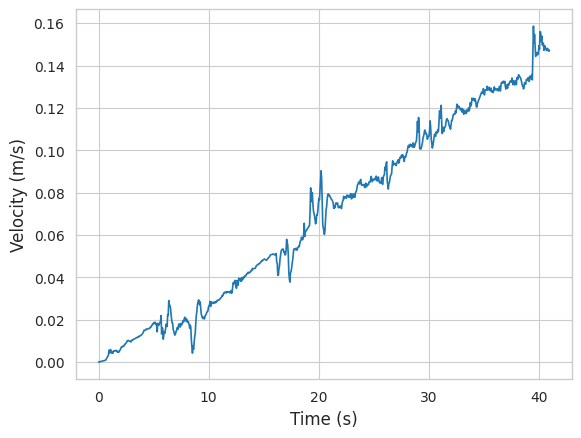

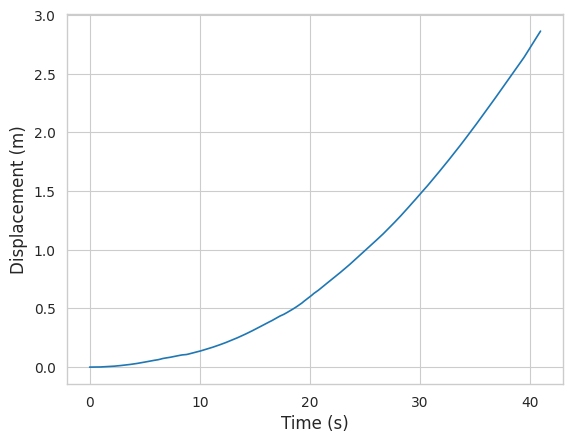

In [52]:
def create_v_d(accs,imus):
    window=0
    iterator=0
    value=0
    vels=[]
    prev_time=imus.iloc[0]["Timestamp"]
    
    prev_acc=0
    prev_vel=0
    for x in imus.iloc:
        bias=imus.iloc[window][accs]
            #Avg acc * dt = dv
        #vel_d=0.5*(prev_acc+x[accs]-2*bias)*(x["Timestamp"]-prev_time)
        vel_d = (x[accs] - bias) * (x["Timestamp"]-prev_time)
        #vel=vel_d
        vel=prev_vel+vel_d
        prev_vel=vel
        prev_time=x["Timestamp"]
        prev_acc=x[accs]
        vels.append(vel)
        iterator+=1
        if(value!=0):
            if(iterator%value==0):
                window+=value
    plt.figure()
    plt.ylabel("Velocity (m/s)")
    plt.xlabel("Time (s)")
    plt.plot(np.array(imus.iloc[:]["Timestamp"]-imus["Timestamp"][0]),vels)
    i=0
    prev_s=0
    prev_v=0
    prev_time=imus.iloc[0]["Timestamp"]
    dists=[]
    window=0
    iterator=0
    for x in imus.iloc:
        bias=imus.iloc[window][accs]
            #Avg acc * dt = dv
        #bias=0
        # velocity


# position
        s = prev_s + prev_vel * (x["Timestamp"]-prev_time)+ + 0.5 * (x[accs] - bias) * (x["Timestamp"]-prev_time)**2
        #s=prev_s+vels[i]*(x["Timestamp"]-prev_time)+0.5*0.5*(prev_acc+x[accs]-2*bias)*np.square(x["Timestamp"]-prev_time)
        #s=prev_s+(vels[i])*(x["Timestamp"]-prev_time)
        prev_s=s
        prev_vel=vels[i]
        prev_acc=x[accs]
        prev_time=x["Timestamp"]
        dists.append(s)
        i+=1
        iterator+=1
        if(value!=0):
            if(iterator%value==0):
                window+=value
    plt.figure()
    plt.ylabel("Displacement (m)")
    plt.xlabel("Time (s)")
    plt.plot(np.array(imus.iloc[:]["Timestamp"]-imus["Timestamp"][0]),dists)
    print(bias)
    return vels,dists
#z_v,z_d=create_v_d("IMU_Raw_z",df2)
#y_v,y_d=create_v_d("IMU_Raw_y",df2)
#x_v,x_d=create_v_d("IMU_Raw_x",df2)
#z_v_st,z_d_st=create_v_d("IMU_Linear_Acc_Z",df2_st)
#y_v_st,y_d_st=create_v_d("IMU_Linear_Acc_Y",df2_st)
#x_v_st,x_d_st=create_v_d("IMU_Linear_Acc_X",df2_st)
x_v_nt_st,x_d_nt_st=create_v_d("Filtered_X",trial)

y_v_nt_st,y_d_nt_st=create_v_d("IMU_Linear_Acc_X",trial)

x_v_nt_st,x_d_nt_st=create_v_d("Filtered_Y",trial)

y_v_nt_st,y_d_nt_st=create_v_d("IMU_Linear_Acc_Y",trial)

z_v_nt_st,z_d_nt_st=create_v_d("Filtered_Z",trial)

z_v_nt_st,z_d_nt_st=create_v_d("IMU_Linear_Acc_Z",trial)

In [53]:
imus[-1]

'/home/saab/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/Condition_1_IMU_only_2026_04_20_17_29_09.bag/output_IMU_case_Condition_1_2026_04_20_17_29_09.bag.csv'

In [54]:
trial2=pd.read_csv(cases[-1])

In [55]:
trial=pd.read_csv(imus[-2])

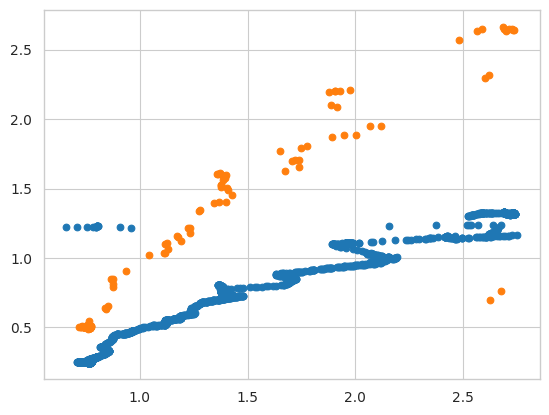

In [56]:
plt.scatter(trial["Pose_Y"][:],trial["Pose_X"][:]/2)
plt.scatter(trial2["Sonar_distance_2"]/1000,trial2["Sonar_distance_1"]/1000)
#plt.ylim(1,2)

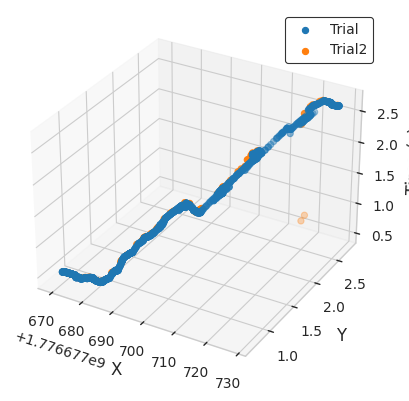

In [57]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(trial["Timestamp"][:],trial["Pose_Y"][:], trial["Pose_X"][:], label='Trial')
ax.scatter(trial2["Timestamp"][:],trial2["Sonar_distance_2"]/1000, trial2["Sonar_distance_1"]/1000, label='Trial2')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Time (s)')
ax.legend()
plt.show()

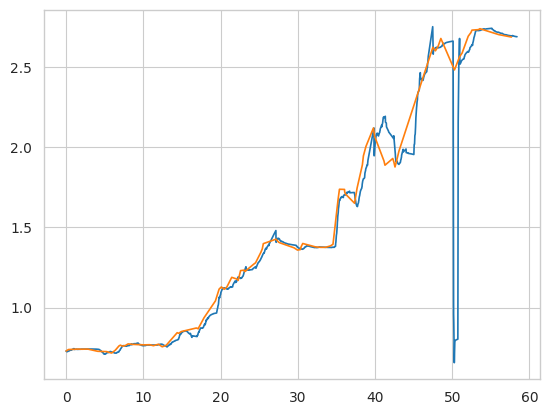

In [58]:
plt.plot(trial["Timestamp"]-trial["Timestamp"][0],trial["Pose_Y"])
plt.plot(trial2["Timestamp"]-trial2["Timestamp"][0],trial2["Sonar_distance_2"]/1000)

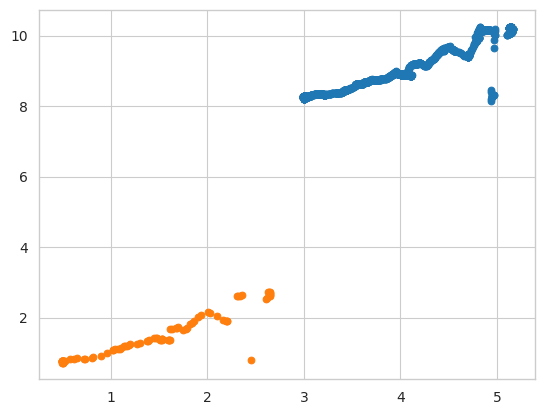

In [59]:
plt.scatter(trial["Pose_X"]+2.5,trial["Pose_Y"]+7.5)
plt.scatter(trial2["Pose_X"],trial2["Pose_Y"])

/tmp/ipykernel_2032966/1906794562.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


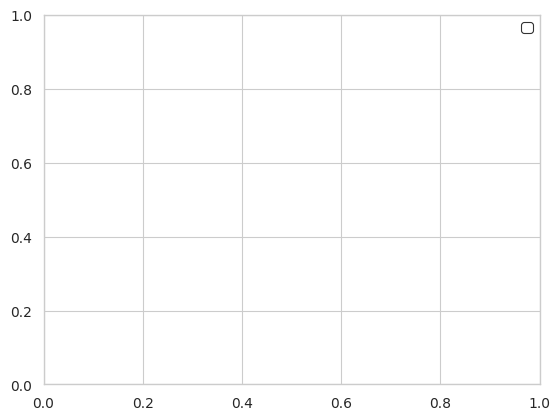

In [60]:
iterator=0
for file in imus[5:]:
    df=pd.read_csv(file)
    plt.scatter(df["Pose_X"],df["Pose_Y"],label=iterator)
    iterator+=1
plt.legend()

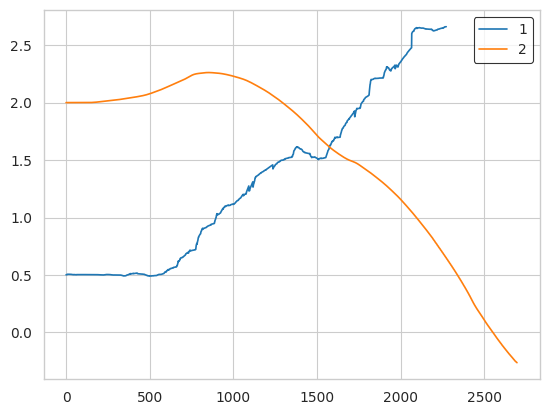

In [61]:
iterator=0
for file in imus[:]:
    df=pd.read_csv(file)
    if(iterator<len(imus)-1):
        plt.plot(df["Pose_X"],label=iterator+1)
    else:
        plt.plot(df["Pose_X"]+2,label=iterator+1)
    iterator+=1
plt.legend()

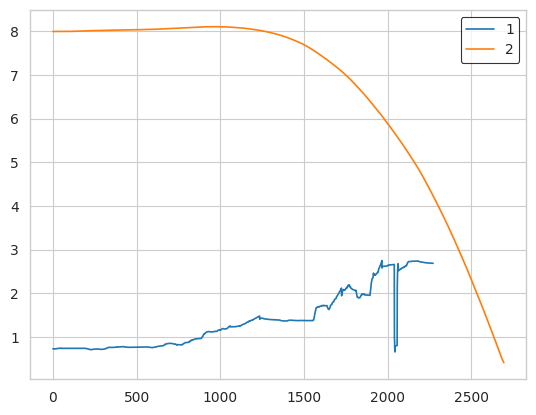

In [62]:
iterator=0
for file in imus[:]:
    df=pd.read_csv(file)
    if(iterator<len(imus)-1):
        plt.plot(df["Pose_Y"],label=iterator+1)
    else:
        plt.plot(df["Pose_Y"]+8,label=iterator+1)
    iterator+=1
plt.legend()

In [63]:
imus

['/home/saab/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/Condition_1_2026_04_20_17_34_03.bag/output_IMU_case_Condition_1_2026_04_20_17_34_03.bag.csv',
 '/home/saab/2024_UWR/Analysis/2026_article/Stepper_not_aligned/Selected/Condition_1_IMU_only_2026_04_20_17_29_09.bag/output_IMU_case_Condition_1_2026_04_20_17_29_09.bag.csv']

In [64]:
test=[imus[-2]]

In [65]:
test2=[cases[17],cases[16],cases[15],cases[12],cases[-1]]
test=[imus[17],imus[16],imus[15],imus[13],imus[-2]]
print(test2)
print(test)

IndexError: list index out of range

In [ ]:
gt

['/home/saab/2024_UWR/Analysis/gt/13Nov/output_1302.csv',
 '/home/saab/2024_UWR/Analysis/gt/13Nov/output_corrected_1302.csv']

In [ ]:
#1302
gt_df=pd.read_csv(gt[0])
div_flows_mean=gt_df["Z"].to_numpy()
#displacements=np.sqrt(gt_df["X"].to_numpy()**2 + gt_df["Y"].to_numpy()**2)
displacements_x=gt_df["X"].to_numpy()
displacements_z=gt_df["Y"].to_numpy()
# Calculate cumulative displacement
displacements=np.sqrt(gt_df["X"].to_numpy()**2 + gt_df["Y"].to_numpy()**2)
cumulative_displacement_x = np.cumsum(div_flows_mean)
cumulative_displacement_y =np.cumsum(displacements)
cumulative_displacement_z =np.cumsum(displacements_z)*0.001
cumulative_displacement_x*=-0.1/abs(cumulative_displacement_x[0]-cumulative_displacement_x[cumulative_displacement_x.shape[0]-1])
cumulative_displacement_y*=6/abs(cumulative_displacement_y[0]-cumulative_displacement_y[cumulative_displacement_y.shape[0]-1])
cumulative_displacement_x+=1.28
cumulative_displacement_y=7.65-cumulative_displacement_y

In [ ]:
df=pd.read_csv(imus[0])
imus[0]

'/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/Condition_31_2026_04_16_15_44_31.bag/output_IMU_case_Condition_31_2026_04_16_15_44_31.bag.csv'

In [ ]:
gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [ ]:
cases[0]

'/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Selected/Condition_31_2026_04_16_15_44_31.bag/output_case_Condition_31_2026_04_16_15_44_31.bag.csv'

In [ ]:
df2=pd.read_csv(cases[0])

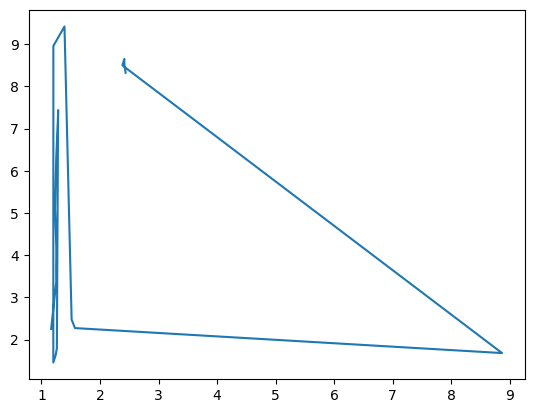

In [ ]:
plt.plot(df2["Sonar_distance_1"]/1000,df2["Sonar_distance_2"]/1000,label="Sonar")

KF error _X 0.4926523869177958
KF error _Y 2.835474674683877


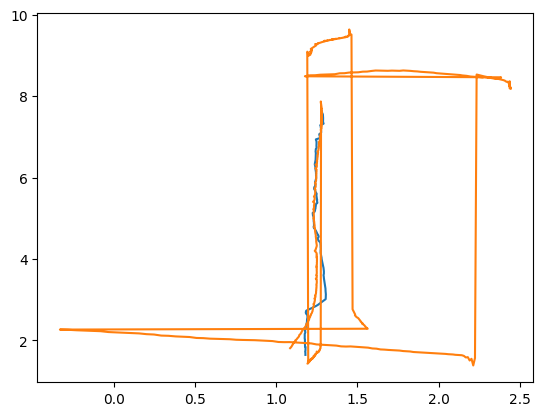

In [ ]:
plt.plot(gt_interp_x,gt_interp_y,label="GT")
plt.plot(df["Pose_X"],df["Pose_Y"],label="IMU")
rmse_val_imu_x=np.sqrt(((gt_interp_x[:] -df["Pose_X"][:]) ** 2).mean())
rmse_val_imu_y=np.sqrt(((gt_interp_y[:] -df["Pose_Y"][:]) ** 2).mean())
print("KF error _X",rmse_val_imu_x
      )
print("KF error _Y",rmse_val_imu_y
      )

In [ ]:
gt_interp_x=np.interp(df2["Timestamp"]-df2["Timestamp"][0],np.linspace(0,df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y=np.interp(df2["Timestamp"]-df2["Timestamp"][0],np.linspace(0,df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z=np.interp(df2["Timestamp"]-df2["Timestamp"][0],np.linspace(0,df2["Timestamp"][len(df2)-1]-df2["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

Sonar error _X 1.6992722107152827
Sonar error _Y 2.700962159130231


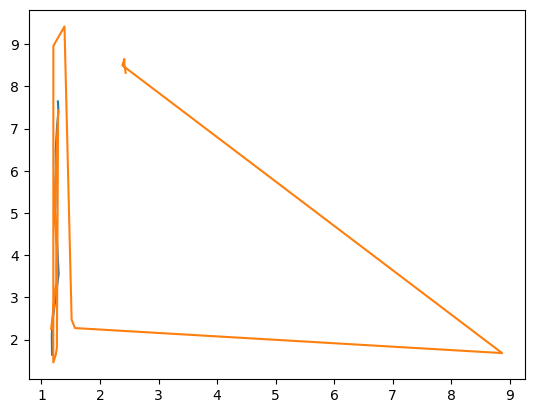

In [ ]:
plt.plot(gt_interp_x,gt_interp_y,label="GT")
#plt.plot(df["Pose_X"],df["Pose_Y"],label="IMU")
plt.plot(df2["Sonar_distance_1"]/1000,df2["Sonar_distance_2"]/1000,label="Sonar")
rmse_val_son_x=np.sqrt(((gt_interp_x[:] -df2["Sonar_distance_1"]/1000) ** 2).mean())
rmse_val_son_y=np.sqrt(((gt_interp_y[:] -df2["Sonar_distance_2"]/1000) ** 2).mean())
print("Sonar error _X",rmse_val_son_x
      )
print("Sonar error _Y",rmse_val_son_y
      )

/home/saab/2024_UWR/Analysis/2026_article/1205_Rope/Selected/Condition1_2026_04_14_16_16_25.bag/output_IMU_case_Condition1_2026_04_14_16_16_25.bag.csv


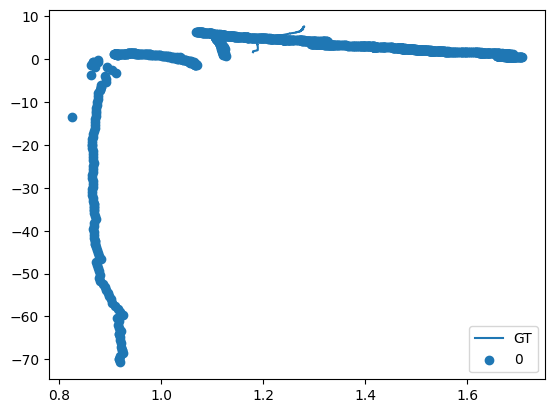

In [ ]:
iterator=0
plt.plot(cumulative_displacement_x,cumulative_displacement_y,label="GT")
for file in test[:2]:
    print(file)
    df=pd.read_csv(file)
    plt.scatter(df["Pose_X"],df["Pose_Y"],label=iterator)
    iterator+=1
plt.legend()

In [ ]:
gt_interp_x=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z=np.interp(df["Timestamp"]-df["Timestamp"][0],np.linspace(0,df["Timestamp"][len(df)-1]-df["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [ ]:
rmse_val_sbs_x=np.sqrt((np.abs(gt_interp_x-df["Sonar_distance_1"]/1000).mean())**2)
rmse_val_sbs_y=np.sqrt((np.abs(gt_interp_y-df["Sonar_distance_2"]/1000).mean())**2)
rmse_val_sbs_z=np.sqrt((np.abs(gt_interp_z-(df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000).mean())**2)

In [ ]:
rmse_val_imu_x=np.sqrt((np.abs(gt_interp_x-df["Pose_X"]).mean())**2)
rmse_val_imu_y=np.sqrt((np.abs(gt_interp_y-df["Pose_Y"]).mean())**2)
rmse_val_imu_z=np.sqrt((np.abs(gt_interp_z-(df["Pose_Z"]-df["Pose_Z"][0])).mean())**2)

In [ ]:
gt_interp_x-df["Pose_X"]

0    -1.164637
1    -1.155274
2    -1.148815
3    -1.156430
4    -1.220062
5    -1.053777
6    -1.177885
7    -0.301691
8    -0.184701
9     0.010451
10    0.032243
11    0.003189
12   -0.015958
13   -0.033083
14   -0.024811
15    0.039763
16   -0.048256
17   -0.064138
18   -0.073967
19   -0.076926
20   -0.075056
21   -0.073640
22   -0.016668
Name: Pose_X, dtype: float64

In [ ]:
gt_interp_x-df["Sonar_distance_1"]/1000

0    -1.164795
1    -1.156105
2    -1.129013
3    -1.122488
4    -1.134249
5    -7.625017
6    -0.332061
7    -0.280230
8    -0.154491
9     0.021994
10    0.028927
11   -0.012935
12   -0.029784
13   -0.036313
14   -0.022437
15    0.044678
16   -0.045477
17   -0.068342
18   -0.076921
19   -0.077171
20   -0.073690
21   -0.074883
22    0.015205
Name: Sonar_distance_1, dtype: float64

In [ ]:
print(rmse_val_imu_y)

2.2318176808061


In [ ]:
print(rmse_val_sbs_y)

2.3969096249190263


In [ ]:
print(rmse_val_imu_y)

4.660211688100021


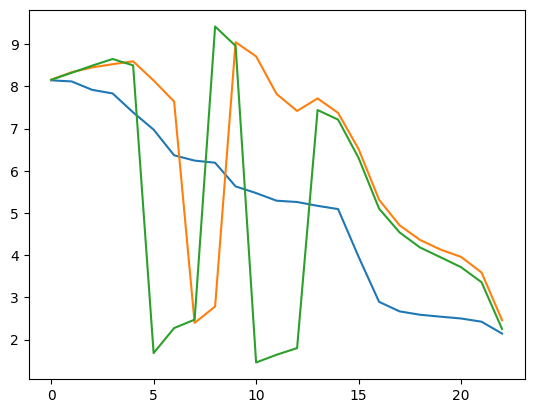

In [ ]:
plt.plot(gt_interp_y+0.5)
plt.plot(df["Pose_Y"])
plt.plot(df["Sonar_distance_2"]/1000)

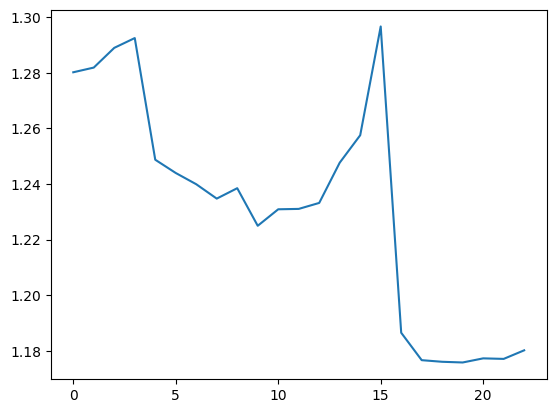

In [ ]:
plt.plot(gt_interp_x)

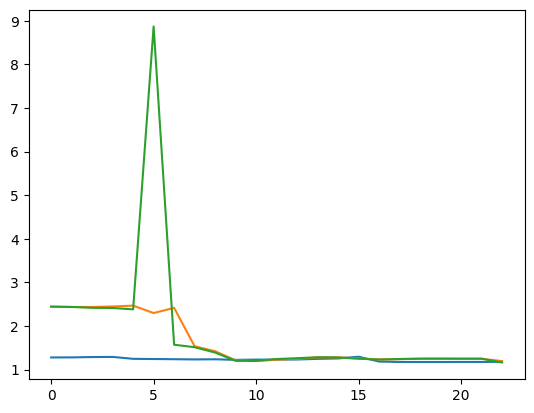

In [ ]:

plt.plot(df["Pose_X"])
plt.plot(df["Sonar_distance_1"]/1000)

In [ ]:
error_check=pd.read_csv(test[0])
gt_interp_x=np.interp(error_check["Timestamp"]-error_check["Timestamp"][0],np.linspace(0,error_check["Timestamp"][len(error_check)-1]-error_check["Timestamp"][0],cumulative_displacement_x.shape[0]),cumulative_displacement_x)
gt_interp_y=np.interp(error_check["Timestamp"]-error_check["Timestamp"][0],np.linspace(0,error_check["Timestamp"][len(error_check)-1]-error_check["Timestamp"][0],cumulative_displacement_y.shape[0]),cumulative_displacement_y)
gt_interp_z=np.interp(error_check["Timestamp"]-error_check["Timestamp"][0],np.linspace(0,error_check["Timestamp"][len(error_check)-1]-error_check["Timestamp"][0],cumulative_displacement_z.shape[0]),cumulative_displacement_z)

In [ ]:
rmse_val_imu_x=np.sqrt((np.abs(gt_interp_x -(error_check["Pose_X"])) ** 2).mean())
rmse_val_imu_y=np.sqrt((np.abs(gt_interp_y -(error_check["Pose_Y"])) ** 2).mean())
rmse_val_imu_z=np.sqrt((np.abs(gt_interp_z -(error_check["Pose_Z"]-error_check["Pose_Z"][0])) ** 2).mean())

In [ ]:
print(rmse_val_imu_y)
print(rmse_val_sbs_y)

2.289974239148748
2.3969096249190263


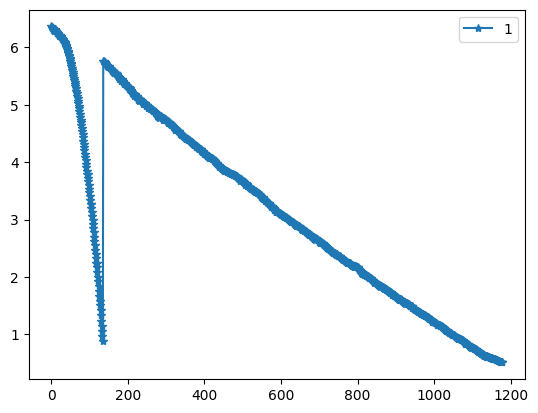

In [ ]:
iterator=0
for file in imus[:]:
    df=pd.read_csv(file)
    #plt.plot(df["Sonar_distance_2"]/1000)
    plt.plot(df["Pose_Y"][:],label=iterator+1,marker="*")
    iterator+=1
plt.legend()

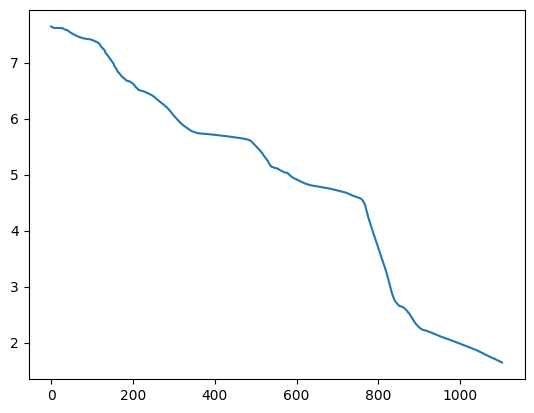

In [ ]:
plt.plot(cumulative_displacement_y)

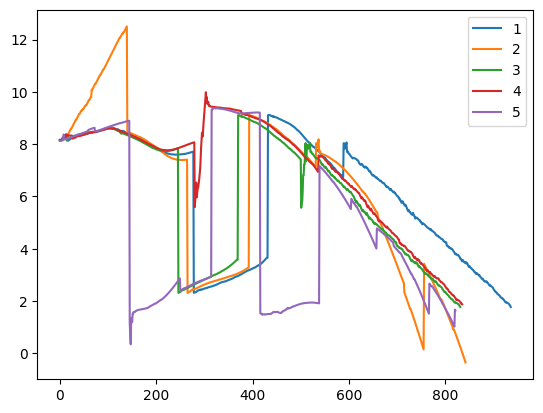

In [ ]:
iterator=0

for file in test[:]:
    df=pd.read_csv(file)
    #plt.plot(df["Sonar_distance_2"]/1000,label="Original")
    plt.plot(df["Pose_Y"],label=iterator+1)
    iterator+=1
plt.legend()

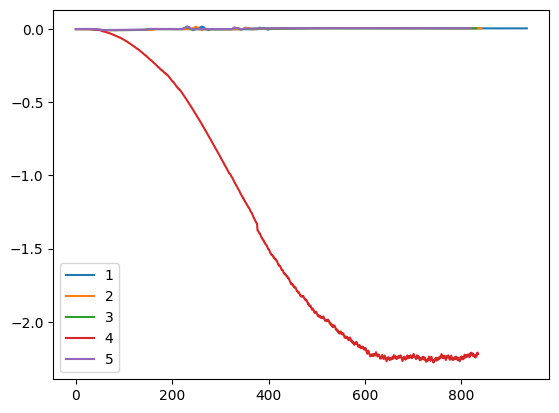

In [ ]:
iterator=0
for file in test[:]:
    df=pd.read_csv(file)
    
    plt.plot(df["Pose_Z"]-df["Pose_Z"][0],label=iterator+1)

    iterator+=1
plt.legend()

/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition23_2026_04_12_20_14_35.bag/output_case_Condition23_2026_04_12_20_14_35.bag.csv
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition22_2026_04_10_17_40_20.bag/output_case_Condition22_2026_04_10_17_40_20.bag.csv
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition21_2026_04_10_17_34_12.bag/output_case_Condition21_2026_04_10_17_34_12.bag.csv
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Default_2026_04_01_14_26_25.bag/output_case_Default_2026_04_01_14_26_25.bag.csv


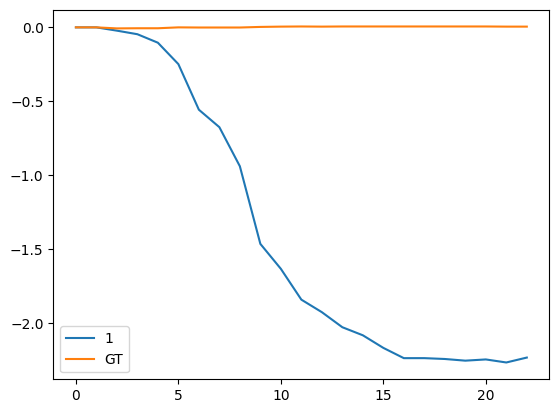

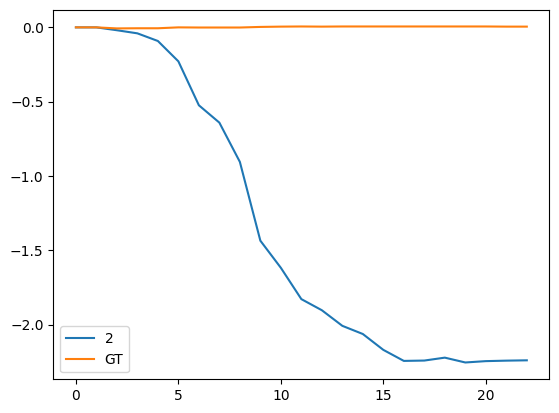

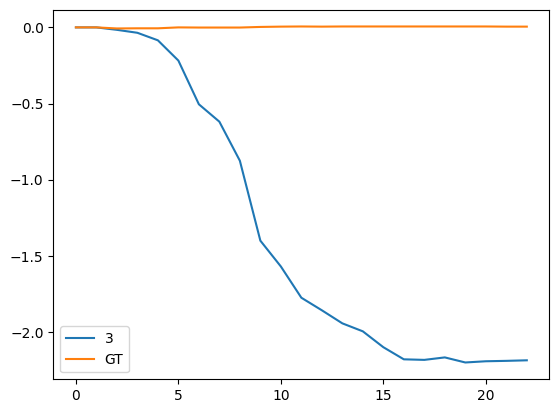

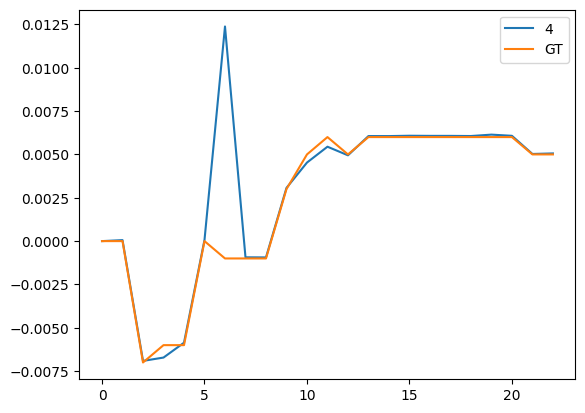

In [ ]:
iterator=0
#plt.plot((df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000,label="GT")
for file in test2[:]:
    plt.figure()
    df=pd.read_csv(file)
    print(file)
    plt.plot(df["Pose_Z"]-df["Pose_Z"][0],label=iterator+1)
    plt.plot((df["Sonar_distance_3"]-df["Sonar_distance_3"][0])/1000,label="GT")
    iterator+=1

    plt.legend()

In [ ]:
diff= 0.1
iterator=0
for file in imus[:]:
    df=pd.read_csv(file)
    if(iterator<len(imus)-1):
        mean=np.mean(df["Pose_Z"]-df["Pose_Z"][0])
        if(np.abs(mean)<=diff):
            print(mean)
            print(file)
            print(iterator)

    iterator+=1
#plt.legend()

0.007029469008115675
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition1_2026_04_01_15_06_20.bag/output_IMU_case_Condition1_2026_04_01_15_06_20.bag.csv
10
0.03510576944500694
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition3_2026_04_01_15_21_49.bag/output_IMU_case_Condition3_2026_04_01_15_21_49.bag.csv
16
0.005964637406347368
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition4_2026_04_01_16_02_37.bag/output_IMU_case_Condition4_2026_04_01_16_02_37.bag.csv
18
0.07963645704331593
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition4_3_2026_04_02_12_12_04.bag_0.db3/output_IMU_case_Condition4_3_2026_04_02_12_12_04.bag_0.db3.csv
20
0.0033544127180102005
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Default_2026_04_01_14_26_25.bag/output_IMU_case_Default_2026_04_01_14_26_25.bag.csv
30


In [ ]:
diff= 1.6
iterator=0
for file in imus[:]:
    df=pd.read_csv(file)
    if(iterator<len(imus)-1):
        mean=np.mean(df["Pose_X"])
        if(np.abs(mean)<=diff):
            print(mean)
            print(file)
            print(iterator)

    iterator+=1

1.4544808159062506
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition10_2026_04_02_15_35_57.bag/output_IMU_case_Condition10_2026_04_02_15_35_57.bag.csv
1
1.5518370299785782
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition4_1_2026_04_02_11_56_33.bag/output_IMU_case_Condition4_1_2026_04_02_11_56_33.bag.csv
12
1.5427415888497893
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition4_2_2026_04_02_12_05_03.bag_0.db3/output_IMU_case_Condition4_2_2026_04_02_12_05_03.bag_0.db3.csv
14
1.5584850533654269
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition4_3_2026_04_02_12_12_04.bag_0.db3/output_IMU_case_Condition4_3_2026_04_02_12_12_04.bag_0.db3.csv
15
1.5471399186460952
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition4_5_2026_04_02_12_25_15.bag/output_IMU_case_Condition4_5_2026_04_02_12_25_15.bag.csv
17
1.5332205839125717
/home/saab/2024_UWR/Analysis/2026_article/1302_Thruster/Condition4_6_2026_04_02_12_36_27.bag/output_

In [ ]:
def score_dataset(y, alpha=5, beta=10.0, gamma=1):
    dy = np.diff(y)

    # spikes = unexpected increases (since signal should decrease)
    spikes = dy[dy > 0]

    spike_count = len(spikes)
    spike_magnitude = np.sum(spikes)
    max_spike = np.max(spikes) if spike_count > 0 else 0

    # smoothness penalty (avoids over-filtering)
    jerk = np.diff(dy)
    jerk_std = np.std(jerk) if len(jerk) > 1 else 0

    score = (
        spike_magnitude +
        alpha * spike_count +
        beta * max_spike +
        gamma * jerk_std
    )

    return score


# datasets = [y1, y2, y3, ...]
scores = []

for i, path in enumerate(imus):
    df=pd.read_csv(path)
    y=df["Pose_Y"]
    s = score_dataset(y)
    scores.append(s)
    print(f"Dataset {i}: score = {s}")

best_idx = np.argmin(scores)

print("\nBest dataset index:", best_idx)
print("Best score:", scores[best_idx])


Dataset 0: score = 1120.735448530394
Dataset 1: score = 2383.523640179377
Dataset 2: score = 1622.9779451717
Dataset 3: score = 2371.6336656459625
Dataset 4: score = 1764.0083081598036
Dataset 5: score = 1814.9467689823325
Dataset 6: score = 1515.1603332948548
Dataset 7: score = 1652.922714520559
Dataset 8: score = 1702.970169115702
Dataset 9: score = 1810.8290260479023
Dataset 10: score = 3258.956881916194
Dataset 11: score = 2168.0699220051233
Dataset 12: score = 1716.4860860441443
Dataset 13: score = 2206.117057388675
Dataset 14: score = 1676.579357922323
Dataset 15: score = 2249.2549603061143
Dataset 16: score = 1554.8746388957345
Dataset 17: score = 2492.801549574885
Dataset 18: score = 1915.8892416164658
Dataset 19: score = 2052.4258554613393
Dataset 20: score = 1645.0512168599273
Dataset 21: score = 2443.304267632799
Dataset 22: score = 1659.134325878655
Dataset 23: score = 2910.5872169508057
Dataset 24: score = 1986.7223242241075
Dataset 25: score = 2383.523640179377
Dataset 26

In [ ]:
df=pd.read_csv(gt[0])
df

,X,Y,Z
0,-0.460263,0.003912,-9.718785e-05
1,0.346120,-0.016591,8.399220e-05
2,0.433882,0.055064,-7.825968e-05
3,0.354715,-0.016800,-2.513435e-04
4,0.244584,0.060989,-1.532622e-04
...,...,...,...
1098,-0.270454,-0.014618,-1.288870e-05
1099,-0.270237,-0.012929,-5.612299e-06
1100,-0.274921,-0.023137,5.009924e-06
1101,-0.279504,-0.016162,-2.840903e-07


KeyError: 'Timestamp'